<img src="./image/spb.jpg" alt="bank" style="width: 100%; height: 100%; object-fit: cover; border-radius: 20px;">

<div style="padding: 10px; background-image: linear-gradient(to right, #FFFBF5, #ECE3CE); border: 2px solid #000; border-radius: 10px; font-family: avenir;">

# <a id='menu'></a> Исследование объявлений о продаже квартир 🏙️


## 🎯 Цель исследования
Выявить основные параметры и факторы, влияющие на рыночную цену квартиры. Это позволит отследить аномалии и мошенническую деятельность при автоматизации процесса оценки.

## 📊 Входные данные
Архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет (real_estate_data.csv).

## 🔍 Ход исследования:

### [1️⃣ Обзор Данных](#first)
- Анализ структуры и содержания датасета
- Выявление потенциальных проблем и ошибок

### [2️⃣ Предобработка Данных](#second)
- ##### Очистка и подготовка данных для анализа, исправление критических ошибок и несоответствий:
   - [`last_price`](#01)
   - [`ponds_nearest`, `ponds_around_3km`, `parks_nearest`, `parks_around_3km`](#02)
   - [`locality_name`](#03)
   - [`airports_nearest`, `city_center_distance`](#04)
   - [`ceiling_height`](#05)
   - [`floors_total`, `floor`](#06)
   - [`balcony`](#07)
   - [`living_area`, `kitchen_area`](#08)
   - [`days_exposition`, `first_day_exposition`](#09)

### [3️⃣ Исследовательский Анализ Данных](#third)
- [Время экспозиции каждого класса](#analysis)
- [Динамика времени экспозиции по классам (в днях)](#dinamic_expo)
- [Корреляция между временем экспозиции и количеством объявлений (по годам)](#corr_expo)
- [Корреляция между временем экспозиции и количеством объявлений (по кварталам)](#corr_expo_quarter)
- [Влияние инфляции, курса доллара и изменения ключевой ставки ЦБ на динамику рынка недвижимости](#usd)
- [Динамика дней экспозиции по классам во времени](#dinamic_expo_time)
- [Поквартальная динамика и структура объявлений по классам жилья](#srtucture)
- [Объявления/Продажи](#sale)
- [Ценовые тренды по сегментам (руб/м²)](#price_trends)
- [Волатильность цен (Коэффициент вариации)](#volatility)
- [Динамика цен по годам](#prices_dynamics)
- [Разрыв между сегментами](#seg_break)
- [Сезонность](#seasonality)
- [Поквартальные продажи по топ-10 городов](#quarter_sales)
- [Цена за м2 по Топ-12 городам](#m2)
- [Доля классов жилья в населенных пунктах](#city_classes)

### [4️⃣ Факторы, влияющие на стоимость недвижимости](#section_4)
- [Стоиммость недвижимости](#last_price)
- [Стоиммость м2 недвижимости](#m2_price)


## 🚀 Ожидаемые результаты
По итогам исследования мы планируем получить глубокое понимание факторов, влияющих на ценообразование квартир в Санкт-Петербурге и окрестностях. Это поможет выявить ключевые параметры для автоматизации оценки стоимости недвижимости и обнаружения потенциальных аномалий или мошеннических действий.

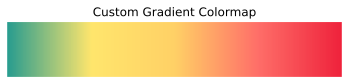

In [1]:
# Ignore Warnings
import warnings

# Data Manipulation
import pandas as pd
import numpy as np

# Data storing
import json

# Progress bar
from tqdm import tqdm


# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import PartialDependenceDisplay

# Data Cleaning
from fuzzywuzzy import fuzz
from itertools import combinations

# Stats
from scipy.stats import chi2_contingency
from scipy import stats
import statsmodels.api as sm

# Modelling
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from lightgbm import LGBMRegressor

# Geodata
from geopy.geocoders import Nominatim
from geopy.distance import geodesic



# Gradient Genrator
from matplotlib.colors import LinearSegmentedColormap

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


%config InlineBackend.figure_format = 'svg'
warnings.filterwarnings('ignore')  # Disabling warning outputs

# Определение цветовых кодов в формате HEX
colors = ['#2a9d8f', '#ffe66d', '#ffd166', '#ff6f69', '#ef233c']

# '#96ceb4',

# Преобразование цветовых кодов в формат RGB
colors_rgb = [tuple(int(color[i:i+2], 16) / 255.0 for i in (1, 3, 5)) for color in colors]

# Создание цветовой карты LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('custom_gradient', colors_rgb)

# Создание градиента от 0 до 1
gradient = np.linspace(0, 1, 256).reshape(1, -1)

# Отображение градиента с использованием созданной цветовой карты
plt.figure(figsize=(6, 1))
plt.imshow(gradient, aspect='auto', cmap=cmap)
plt.axis('off')
plt.title('Custom Gradient Colormap')
plt.show()

## <a id='first'></a> 1️⃣ Обзор данных


[**Главное меню**](#menu)

In [2]:
# Прописываем путь к файлу `data.csv`
DATAPATH = './data/real_estate_data.csv'

# Read the training data into a pandas DataFrame
df = pd.read_csv(DATAPATH, sep='\t')

In [3]:
# Отображаем первые 5 наблюдений
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [4]:
# Выводим список названий столбцов DataFrame
df.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition'],
      dtype='object')

### Документация к данным

- `airports_nearest` — расстояние до ближайшего аэропорта в метрах (м)
- `balcony` — число балконов
- `ceiling_height` — высота потолков (м)
- `cityCenters_nearest` — расстояние до центра города (м)
- `days_exposition` — сколько дней было размещено объявление (от публикации до снятия)
- `first_day_exposition` — дата публикации
- `floor` — этаж
- `floors_total` — всего этажей в доме
- `is_apartment` — апартаменты (булев тип)
- `kitchen_area` — площадь кухни в квадратных метрах (м²)
- `last_price` — цена на момент снятия с публикации
- `living_area` — жилая площадь в квадратных метрах (м²)
- `locality_name` — название населённого пункта
- `open_plan` — свободная планировка (булев тип)
- `parks_around3000` — число парков в радиусе 3 км
- `parks_nearest` — расстояние до ближайшего парка (м)
- `ponds_around3000` — число водоёмов в радиусе 3 км
- `ponds_nearest` — расстояние до ближайшего водоёма (м)
- `rooms` — число комнат
- `studio` — квартира-студия (булев тип)
- `total_area` — площадь квартиры в квадратных метрах (м²)
- `total_images` — число фотографий квартиры в объявлении

In [5]:
df.rename(columns={'cityCenters_nearest':'city_center_distance', 'parks_around3000':'parks_around_3km', 'ponds_around3000':'ponds_around_3km'}, inplace=True)

In [6]:
# Выводим первые 5 строк DataFrame
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_center_distance,parks_around_3km,parks_nearest,ponds_around_3km,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [7]:
# Выводим общую информацию о DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [8]:
df.dtypes

total_images              int64
last_price              float64
total_area              float64
first_day_exposition     object
rooms                     int64
ceiling_height          float64
floors_total            float64
living_area             float64
floor                     int64
is_apartment             object
studio                     bool
open_plan                  bool
kitchen_area            float64
balcony                 float64
locality_name            object
airports_nearest        float64
city_center_distance    float64
parks_around_3km        float64
parks_nearest           float64
ponds_around_3km        float64
ponds_nearest           float64
days_exposition         float64
dtype: object

In [9]:
# Подсчитываем количество пропущенных значений в каждом столбце DataFrame
df.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_center_distance     5519
parks_around_3km         5518
parks_nearest           15620
ponds_around_3km         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

In [10]:
# Подсчитываем количество пропущенных значений в каждом столбце DataFrame
pd.DataFrame(df.isna().sum() / len(df) * 100).reset_index().rename(columns={'index':'feature', 0:'missing %'})

,feature,missing %
0,total_images,0.000000
1,last_price,0.000000
2,total_area,0.000000
3,first_day_exposition,0.000000
4,rooms,0.000000
5,ceiling_height,38.799105
6,floors_total,0.362885
7,living_area,8.029875
8,floor,0.000000
9,is_apartment,88.290645


In [11]:
# Выводим статистическое описание столбцов DataFrame
df.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,city_center_distance,parks_around_3km,parks_nearest,ponds_around_3km,ponds_nearest,days_exposition
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,12180.000000,18157.000000,18180.000000,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000
mean,9.858475,6.541549e+06,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,1.150082,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.980900,180.888634
std,5.682529,1.088701e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,1.071300,12630.880622,8608.386210,0.802074,342.317995,0.938346,277.720643,219.727988
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,18585.000000,9238.000000,0.000000,288.000000,0.000000,294.000000,45.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,1.000000,26726.000000,13098.500000,0.000000,455.000000,1.000000,502.000000,95.000000
75%,14.000000,6.800000e+06,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,2.000000,37273.000000,16293.000000,1.000000,612.000000,1.000000,729.000000,232.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000


In [12]:
# Выводим статистическое описание столбцов DataFrame
df.describe(include='object')

,first_day_exposition,is_apartment,locality_name
count,23699,2775,23650
unique,1491,2,364
top,2018-02-01T00:00:00,False,Санкт-Петербург
freq,368,2725,15721


In [13]:
# Выводим типы данных каждого столбца DataFrame
df.dtypes

total_images              int64
last_price              float64
total_area              float64
first_day_exposition     object
rooms                     int64
ceiling_height          float64
floors_total            float64
living_area             float64
floor                     int64
is_apartment             object
studio                     bool
open_plan                  bool
kitchen_area            float64
balcony                 float64
locality_name            object
airports_nearest        float64
city_center_distance    float64
parks_around_3km        float64
parks_nearest           float64
ponds_around_3km        float64
ponds_nearest           float64
days_exposition         float64
dtype: object

## <a id='second'></a> 2️⃣ Предобработка данных


[**Главное меню**](#menu)

In [14]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

is_apartment            20924
parks_nearest           15620
ponds_nearest           14589
balcony                 11519
ceiling_height           9195
airports_nearest         5542
city_center_distance     5519
parks_around_3km         5518
ponds_around_3km         5518
days_exposition          3181
kitchen_area             2278
living_area              1903
floors_total               86
locality_name              49
dtype: int64

#### Проверим датасет на наличие явных дуликатов

In [15]:
df.duplicated().sum()

0

### <a id='01'></a> `last_price`

In [16]:
df['last_price'].value_counts().sort_index()

last_price
12190.0        1
430000.0       2
440000.0       1
450000.0       4
470000.0       3
              ..
300000000.0    1
330000000.0    1
401300000.0    1
420000000.0    1
763000000.0    1
Name: count, Length: 2978, dtype: int64

##### На мой взляд 12190.0 - это аномальное значение с учетом данных конкретно этого наблюдения, полагаю, что стоимость нужно умножить на 1000

In [17]:
df.loc[df['last_price'] == 12190.0, 'last_price'] = df.loc[df['last_price'] == 12190.0, 'last_price'] * 1000

#### Самое высокое значение стоимости похоже на объявление о продаже элитного жилья (3км от центра города, 400м2)

In [18]:
df.loc[df['last_price'] == 763000000.0]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_center_distance,parks_around_3km,parks_nearest,ponds_around_3km,ponds_nearest,days_exposition
12971,19,763000000.0,400.0,2017-09-30T00:00:00,7,NaN,10.0,250.0,10,NaN,...,NaN,2.0,Санкт-Петербург,25108.0,3956.0,1.0,530.0,3.0,756.0,33.0


### <a id='02'></a> `ponds_nearest`, `ponds_around_3km`, `parks_nearest`, `parks_around_3km`

#### Стратегия обработки данных о парках и прудах

1. **Анализ данных о прудах**:
   - Подсчет количества уникальных значений в столбце 'ponds_around_3km'
   - Применение логического условия: если 'ponds_around_3km' = 0, то 'ponds_nearest' = 0

2. **Анализ данных о парках**:
   - Подсчет количества уникальных значений в столбце 'parks_around_3km'
   - Применение логического условия: если 'parks_around_3km' = 0, то 'parks_nearest' = 0

3. **Заполнение пропущенных значений**:
   - Определение столбцов для заполнения: 'parks_around_3km', 'ponds_around_3km', 'parks_nearest', 'ponds_nearest'
   - Заполнение всех пропущенных значений в этих столбцах нулями

4. **Проверка результатов** (неявно присутствует в коде через повторные вызовы value_counts()):
   - Повторный подсчет уникальных значений после каждого этапа обработки для контроля изменений


In [19]:
# Подсчет количества уникальных значений в столбце 'ponds_around_3km'
df['ponds_around_3km'].value_counts()

ponds_around_3km
0.0    9071
1.0    5717
2.0    1892
3.0    1501
Name: count, dtype: int64

In [20]:
# Установка значения 0 в столбце 'ponds_nearest' для строк, где 'ponds_around_3km' равно 0
df.loc[df['ponds_around_3km'] == 0, 'ponds_nearest'] = 0

In [21]:
# Подсчет количества уникальных значений в столбце 'parks_around_3km'
df['parks_around_3km'].value_counts()

parks_around_3km
0.0    10106
1.0     5681
2.0     1747
3.0      647
Name: count, dtype: int64

In [22]:
# Установка значения 0 в столбце 'parks_nearest' для строк, где 'parks_around_3km' равно 0
df.loc[df['parks_around_3km'] == 0, 'parks_nearest'] = 0

In [23]:
# Заполнение пропущенных значений нулями в указанных столбцах
columns_to_fill = ['parks_around_3km', 'ponds_around_3km', 'parks_nearest', 'ponds_nearest']
df[columns_to_fill] = df[columns_to_fill].fillna(0)

In [24]:
# Подсчет и сортировка количества пропущенных значений в столбцах, где они есть
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

is_apartment            20924
balcony                 11519
ceiling_height           9195
airports_nearest         5542
city_center_distance     5519
days_exposition          3181
kitchen_area             2278
living_area              1903
floors_total               86
locality_name              49
dtype: int64

### <a id='03'></a> `locality_name`

### Стратегия заполнения пропусков

1. **Выбор данных**:
   - Создание набора без пропусков для обучения
   - Создание тестового набора с пропусками в 'locality_name'

2. **Подготовка данных**:
   - Кодирование категориальных переменных
   - Разделение на признаки и целевую переменную

3. **Моделирование**:
   - Использование RandomForestClassifier
   - Обучение на данных без пропусков

4. **Прогнозирование**:
   - Предсказание пропущенных значений 'locality_name'
   - Обратное преобразование меток в названия

5. **Заполнение пропусков**:
   - Обновление исходного DataFrame предсказанными значениями

In [25]:
# Замена буквы 'ё' на 'е' в столбце 'locality_name'
df['locality_name'] = df['locality_name'].str.replace('ё', 'е')

In [26]:
# Создание нового DataFrame X_locality с выбранными столбцами и строками без пропущенных значений
X_locality = df.loc[(~df['city_center_distance'].isna())
        & (~df['parks_around_3km'].isna())
        & (~df['parks_nearest'].isna())
        & (~df['ponds_around_3km'].isna())
        & (~df['ponds_nearest'].isna())
        & (~df['airports_nearest'].isna())
        & (~df['locality_name'].isna()),
        ['city_center_distance', 'parks_around_3km', 'parks_nearest', 'ponds_around_3km', 'ponds_nearest', 'airports_nearest', 'locality_name']]

# Вывод первых 5 строк нового DataFrame
X_locality.head()

,city_center_distance,parks_around_3km,parks_nearest,ponds_around_3km,ponds_nearest,airports_nearest,locality_name
0,16028.0,1.0,482.0,2.0,755.0,18863.0,Санкт-Петербург
1,18603.0,0.0,0.0,0.0,0.0,12817.0,поселок Шушары
2,13933.0,1.0,90.0,2.0,574.0,21741.0,Санкт-Петербург
3,6800.0,2.0,84.0,3.0,234.0,28098.0,Санкт-Петербург
4,8098.0,2.0,112.0,1.0,48.0,31856.0,Санкт-Петербург


In [27]:
# Создание тестового DataFrame TEST с выбранными столбцами и строками, где 'locality_name' пустое, а остальные столбцы не содержат пропущенных значений
TEST = df.loc[(~df['city_center_distance'].isna())
        & (~df['parks_around_3km'].isna())
        & (~df['parks_nearest'].isna())
        & (~df['ponds_around_3km'].isna())
        & (~df['ponds_nearest'].isna())
        & (~df['airports_nearest'].isna())
        & (df['locality_name'].isna()),
        ['city_center_distance', 'parks_around_3km', 'parks_nearest', 'ponds_around_3km', 'ponds_nearest', 'airports_nearest']]


### Проверка на неявные дубликаты

In [28]:
# Функция для поиска похожих жанров
def find_similar_areas(areas, threshold=60):
    similar_pairs = []
    for area1, area2 in combinations(areas, 2):
        # Вычисляем схожесть строк
        similarity = fuzz.ratio(area1.lower(), area2.lower())
        if similarity >= threshold:
            similar_pairs.append((area1, area2, similarity))
    # Сортируем пары по убыванию схожести
    return sorted(similar_pairs, key=lambda x: x[2], reverse=True)

# Получаем уникальные жанры и сортируем их
areas = sorted(X_locality['locality_name'].str.replace('поселок ', '').unique())

# Находим похожие жанры
similar_areas = find_similar_areas(areas)

# Выводим результаты
for area1, area2, similarity in similar_areas:
    print(f"'{area1}' и '{area2}' похожи на {similarity}%")

'Мурино' и 'Репино' похожи на 67%
'Белоостров' и 'Металлострой' похожи на 64%
'Белоостров' и 'Ломоносов' похожи на 63%
'Колпино' и 'Репино' похожи на 62%
'Парголово' и 'Щеглово' похожи на 62%
'Песочный' и 'Саперный' похожи на 62%


In [29]:
# Инициализация кодировщика меток
encoder = LabelEncoder()

# Преобразование столбца 'locality_name' в числовые метки
X_locality['locality_name'] = encoder.fit_transform(X_locality['locality_name'])

# Создание матрицы признаков X, исключая столбец 'locality_name', и сброс индекса
X = X_locality.drop(columns=['locality_name']).reset_index(drop=True)

# Создание вектора целевой переменной y из закодированного столбца 'locality_name' и сброс индекса
y = X_locality['locality_name'].reset_index(drop=True)

In [30]:

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Инициализация и обучение модели случайного леса
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = model.predict(X_test)

# Вычисление точности модели
accuracy = accuracy_score(y_test, y_pred)

# вывод точности модели
print(f'Точность модели: {accuracy:.3f}')

Точность модели: 0.995


In [31]:
# Предсказание меток для тестового набора данных TEST
y_predicted = model.predict(TEST)

# Обратное преобразование числовых меток в исходные названия населенных пунктов
encoder.inverse_transform(y_predicted)

# Вывод предсказанных названий населенных пунктов
print(encoder.inverse_transform(y_predicted))

['Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург'
 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург'
 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург'
 'Санкт-Петербург' 'Санкт-Петербург' 'Пушкин' 'Санкт-Петербург'
 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург'
 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург'
 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург'
 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург'
 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург' 'Пушкин'
 'поселок Репино' 'Санкт-Петербург' 'Санкт-Петербург' 'Санкт-Петербург'
 'Санкт-Петербург']


In [32]:
# Заполнение пропущенных значений в столбце 'locality_name' предсказанными названиями населенных пунктов
df.loc[TEST.index, 'locality_name'] = encoder.inverse_transform(y_predicted)

In [33]:
# Удаление строк с пропущенными значениями в столбце 'locality_name' и сброс индекса
df = df[~df['locality_name'].isna()].reset_index(drop=True)

In [34]:
# Подсчет и сортировка количества пропущенных значений в столбцах, где они есть
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

is_apartment            20921
balcony                 11515
ceiling_height           9189
airports_nearest         5534
city_center_distance     5511
days_exposition          3180
kitchen_area             2276
living_area              1902
floors_total               86
dtype: int64

### <a id='04'></a> `airports_nearest`, `city_center_distance`

### Стратегия заполнения пропусков

1. **Подготовка данных**:
   - Выбор строк с пропусками в 'city_center_distance' и 'airports_nearest'
   - Очистка названий населенных пунктов от префиксов

2. **Геокодирование**:
   - Использование Nominatim для получения координат

3. **Расчет расстояний**:
   - До центра Санкт-Петербурга
   - До аэропорта Пулково

4. **Оптимизация**:
   - Кэширование результатов для ускорения процесса
   - Использование прогресс-бара для отслеживания выполнения

5. **Обработка исключений**:
   - Повторная обработка пропущенных значений
   - Индивидуальный подход к оставшимся пропускам

6. **Заполнение пропусков**:
   - Обновление исходного DataFrame рассчитанными расстояниями

In [35]:
# Определение списка признаков для обработки
features = ['airports_nearest', 'city_center_distance', 'parks_around_3km', 'parks_nearest', 'ponds_around_3km', 'ponds_nearest', 'last_price', 'locality_name', 'total_area', 'rooms']

# Выбор строк, где 'city_center_distance' и 'airports_nearest' имеют пропущенные значения
to_fill = df.loc[(df['city_center_distance'].isna())
            & (df['airports_nearest'].isna()),
            features]

In [36]:
# Список префиксов для удаления из названий населенных пунктов
to_drop = ['городской поселок ', 'деревня ', 'поселок городского типа ', 'садовое товарищество ', 'село ', 'коттеджный поселок ', 'поселок станции ', 'садоводческое некоммерческое товарищество ',
           'поселок при железнодорожной станции ', 'поселок ']

# Функция для обработки названий населенных пунктов
def replace_prefixes(x):
    if isinstance(x, str):
        for prefix in to_drop:
            x = x.replace(prefix, '')
    if x == 'Шушары' or x == 'Кронштадт':
        return x
    if x == 'Платформа 69-й километр':
        return "60.509943, 30.229809"
    return x + ',  Ленинградская область'

# Применение функции replace_prefixes к строковым столбцам DataFrame to_fill
to_fill = to_fill.apply(lambda col: col.apply(replace_prefixes) if col.dtype == 'object' else col)

In [38]:
geolocator = Nominatim(user_agent="my_agent")


# Словарь для кэширования результатов
distance_cache = {}

def distance(x, area):
    if not isinstance(x, str):
        return None
    
    # Проверяем, есть ли результат в кэше
    if x in distance_cache:
        return distance_cache[x]
    
    try:
        place_to_fill = geolocator.geocode(x)
        if place_to_fill is None:
            distance_cache[x] = None
            return None
        
        dist = geodesic((area.latitude, area.longitude), (place_to_fill.latitude, place_to_fill.longitude)).meters
        distance_cache[x] = dist
        return dist
    except Exception as e:
        print(f"Ошибка при обработке '{x}': {str(e)}")
        distance_cache[x] = None
        return None
    

# Функция для применения distance с прогресс-баром
def apply_with_progress(series, area):

    # Получаем координаты населенного пункта один раз
    area = geolocator.geocode(area)
    if area is None:
        raise ValueError("Не удалось получить координаты населенного пункта")

    # Настройка цветов для tqdm
    tqdm.pandas(
        desc="Вычисление расстояний",
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed} < {remaining}]",
        colour='#5bb9a9',  # Основной цвет прогресс-бара
        ncols=100  # Ширина прогресс-бара
    )
    return series.progress_apply(lambda x: distance(x, area))

# Применяем функцию к столбцу с прогресс-баром для центра города
to_fill['city_center_distance'] = apply_with_progress(to_fill['locality_name'], 'Санкт-Петербург')

# Заполняем пропуски (если нужно)
to_fill['city_center_distance'].fillna(-1, inplace=True)

# Сохраняем кэш для расстояний до центра города
with open('./data/distance_cache_city_center.json', 'w') as f:
    json.dump(distance_cache, f)

# Очищаем словарь перед расчетом расстояний до аэропорта
distance_cache.clear()

# Применяем функцию к столбцу с прогресс-баром для аэропорта
to_fill['airports_nearest'] = apply_with_progress(to_fill['locality_name'], 'Аэропорт Пулково')

# Заполняем пропуски (если нужно)
to_fill['airports_nearest'].fillna(-1, inplace=True)

# Сохраняем кэш для расстояний до аэропорта
with open('./data/distance_cache_airport.json', 'w') as f:
    json.dump(distance_cache, f)

Вычисление расстояний: 100%|█████████████████████████████████████████████| 5510/5510 [02:28 < 00:00]


#### заглушка

In [39]:
# def load_from_json(filename):
#     print(f"Загрузка данных из {filename}")
#     with open(filename, 'r') as f:
#         return json.load(f)

# # Загрузка расстояний до центра города
# city_center_distances = load_from_json('.data/distance_cache_city_center.json')

# to_fill['city_center_distance'] = to_fill['locality_name'].map(city_center_distances)
# to_fill['city_center_distance'].fillna(-1, inplace=True)

# # Загрузка расстояний до аэропорта
# airport_distances = load_from_json('.data/distance_cache_airport.json')

# # Применяем загруженные данные
# to_fill['airports_nearest'] = to_fill['locality_name'].map(airport_distances)
# to_fill['airports_nearest'].fillna(-1, inplace=True)

# print("Данные успешно загружены из JSON файлов и применены к DataFrame.")

In [40]:
# Заполнение пропущенных значений в столбцах 'airports_nearest' и 'city_center_distance'
df.loc[(df['city_center_distance'].isna())
            & (df['airports_nearest'].isna()),
            ['airports_nearest', 'city_center_distance']] = to_fill[['airports_nearest', 'city_center_distance']]

In [41]:
# Вывод значений столбца 'locality_name' для строк, где 'city_center_distance' содержит пропущенные значения
df.loc[(df['city_center_distance'].isna())]['locality_name']

20187    Пушкин
Name: locality_name, dtype: object

In [42]:

# Получение списка уникальных названий населенных пунктов с пропущенными значениями в 'city_center_distance'
missing_locations_center = df.loc[(df['city_center_distance'].isna())]['locality_name'].unique().tolist()

for location in missing_locations_center:
    print(f"Обрабатываем: {location}")
    
    # Инициализация геокодера
    geolocator = Nominatim(user_agent="my_agent")

    # Получение координат Санкт-Петербурга и текущего населенного пункта
    spb = geolocator.geocode("Санкт-Петербург")
    location_searched = geolocator.geocode(location)

    # Расчет расстояния между Санкт-Петербургом и текущим населенным пунктом
    distance = geodesic((spb.latitude, spb.longitude), (location_searched.latitude, location_searched.longitude)).meters

    # Заполнение пропущенных значений рассчитанным расстоянием
    df.loc[(df['city_center_distance'].isna()) & (df['locality_name'] == location), 'city_center_distance'] = distance

    # Удаление обработанного населенного пункта из списка
    missing_locations_center.remove(location)
    
    # Проверка завершения обработки
    if not missing_locations_center:
        print('Обработка пропущенных значений завершена.')
    else:
        print(f"Обрабатываем: {location}")

Обрабатываем: Пушкин
Обработка пропущенных значений завершена.


In [43]:
# Получение списка уникальных названий населенных пунктов с пропущенными значениями в 'airports_nearest'
missing_locations_airport = df.loc[(df['airports_nearest'].isna())]['locality_name'].unique().tolist()

for location in missing_locations_airport:
    print(f"Обрабатываем: {location}")

    # Инициализация геокодера
    geolocator = Nominatim(user_agent="my_agent")

    # Получение координат Санкт-Петербурга и текущего населенного пункта
    spb = geolocator.geocode("Санкт-Петербург")
    location_searched = geolocator.geocode(location)

    # Расчет расстояния между Санкт-Петербургом и текущим населенным пунктом
    distance = geodesic((spb.latitude, spb.longitude), (location_searched.latitude, location_searched.longitude)).meters

    # Заполнение пропущенных значений рассчитанным расстоянием
    df.loc[(df['airports_nearest'].isna()) & (df['locality_name'] == location), 'airports_nearest'] = distance

    # Удаление обработанного населенного пункта из списка
    missing_locations_airport.remove(location)

    # Проверка завершения обработки
    if not missing_locations_airport:
        print('Обработка пропущенных значений завершена.')
    else:
        print(f"Обрабатываем: {location}")

Обрабатываем: Санкт-Петербург
Обработка пропущенных значений завершена.


In [44]:
# Подсчет и сортировка количества пропущенных значений в столбцах, где они есть
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

is_apartment       20921
balcony            11515
ceiling_height      9189
days_exposition     3180
kitchen_area        2276
living_area         1902
floors_total          86
dtype: int64

### <a id='05'></a> `ceiling_height`

### Классификация квартир по классам

#### Критерии классификации по общей площади

Я решил разделить квартиры на классы по следующим критериям общей площади:

* Эконом-класс: до 50 м²
* Комфорт-класс: 50-80 м²
* Бизнес-класс: 80-120 м²
* Элит-класс: более 120 м²

#### Процесс классификации

##### Шаг 1: Анализ стоимости квадратного метра

1. Группировка данных по названиям населенных пунктов
2. Расчет квантилей стоимости квадратного метра (50%, 84%, 95.5%)
3. Умножение полученных квантилей на соответствующие квантили общей площади

##### Шаг 2: Создание функции классификации по цене

Разработка функции, которая определяет класс квартиры на основе ее цены и рассчитанных ценовых диапазонов для каждого населенного пункта.

##### Шаг 3: Применение классификации

Применение функции классификации ко всем квартирам в наборе данных.

##### Шаг 4: Обработка данных о высоте потолков

1. Расчет медианной высоты потолков для каждого класса квартир в каждом населенном пункте
2. Создание функции для заполнения пропущенных значений высоты потолков:
   - Если известна высота потолка, используется это значение
   - Если высота неизвестна, используется медианное значение для соответствующего класса и населенного пункта
   - Если медианное значение недоступно, используется общая медианная высота потолков

##### Шаг 5: Заполнение пропущенных значений

Применение функции заполнения высоты потолков ко всем квартирам в наборе данных.

#### Результат

В результате этого процесса каждая квартира в наборе данных получает классификацию на основе ее стоимости, площади и местоположения, а также заполняются пропущенные значения высоты потолков.

#### Сперва мы создаем признак `стоимость м2`

In [45]:
# Расчет цены за квадратный метр и создание нового столбца 'price_per_m2'
df['price_per_m2'] = df['last_price'] / df['total_area']

In [46]:
# считаем кол-во квартир с аномальной высотой потолка 
display((df[df['ceiling_height'] > 5]['ceiling_height'].count() + 
         df[df['ceiling_height'] < 2.5]['ceiling_height'].count()))

109

#### Обнуляем аномально высокие и аномально низкие значения

In [47]:
# Замена значений высоты потолков на NaN, если они меньше 2.5 или больше 5 метров
df.loc[(df['ceiling_height'] < 2.5) | (df['ceiling_height'] > 5), 'ceiling_height'] = np.nan

# Вывод статистических характеристик столбца 'total_area'
df['total_area'].describe()

count    23691.000000
mean        60.346202
std         35.658589
min         12.000000
25%         40.000000
50%         52.000000
75%         69.800000
max        900.000000
Name: total_area, dtype: float64

In [48]:
# Расчет квантилей цен для каждого населенного пункта
price_quantiles = df.groupby('locality_name').agg({
        'price_per_m2': [
            ('q50_area', lambda x: x.quantile(0.5) * df['total_area'].quantile(0.5)),
            ('q84_area', lambda x: x.quantile(0.84) * df['total_area'].quantile(0.84)),
            ('q955_area', lambda x: x.quantile(0.955) * df['total_area'].quantile(0.955))
        ]
    }).reset_index()

# Переименование столбцов
price_quantiles.columns = ['_'.join(col) if not 'locality_name' in col else 'locality_name' for col in price_quantiles.columns]

# Вывод первых 5 строк результата
price_quantiles.head()


,locality_name,price_per_m2_q50_area,price_per_m2_q84_area,price_per_m2_q955_area
0,Бокситогорск,9.027778e+05,1.573921e+06,2.527396e+06
1,Волосово,2.075129e+06,3.786220e+06,6.210802e+06
2,Волхов,1.820000e+06,3.156687e+06,5.143125e+06
3,Всеволожск,3.421053e+06,6.205366e+06,1.077343e+07
4,Выборг,3.024233e+06,5.540844e+06,9.548690e+06


In [49]:
# Функция для классификации недвижимости по ценовому сегменту
def classify_by_price(price, locality, price_quantiles):
    locality_quantiles = price_quantiles[price_quantiles['locality_name'] == locality].iloc[0]
    if price < locality_quantiles['price_per_m2_q50_area']:
        return 'economy'
    elif locality_quantiles['price_per_m2_q50_area'] < price < locality_quantiles['price_per_m2_q84_area']:
        return 'comfort'
    elif locality_quantiles['price_per_m2_q84_area'] < price < locality_quantiles['price_per_m2_q955_area']:
        return 'business'
    elif price > locality_quantiles['price_per_m2_q955_area']:
        return 'elite'

In [50]:
# Применение функции классификации к каждой строке DataFrame и создание нового столбца 'class_by_price'
df['class_by_price'] = df.apply(lambda row: classify_by_price(
    row['last_price'], 
    row['locality_name'], 
    price_quantiles
), axis=1)

In [51]:
# Расчет медианной высоты потолков для каждой комбинации населенного пункта и ценового класса
median_heights = df.groupby(['locality_name', 'class_by_price'])['ceiling_height'].median().reset_index()
mask = median_heights['ceiling_height'].notna()
median_heights_filtered = median_heights[mask]

# Функция для заполнения пропущенных значений высоты потолков
def fill_ceiling_height(row, median_heights_filtered):
    if pd.isna(row['ceiling_height']):
        matching_median = median_heights_filtered[
            (median_heights_filtered['locality_name'] == row['locality_name']) & 
            (median_heights_filtered['class_by_price'] == row['class_by_price'])
        ]
        if not matching_median.empty:
            return matching_median['ceiling_height'].values[0]

        return df['ceiling_height'].median()
    return row['ceiling_height']

# Применение функции заполнения к столбцу 'ceiling_height'
df['ceiling_height'] = df.apply(lambda row: fill_ceiling_height(row, median_heights_filtered), axis=1)

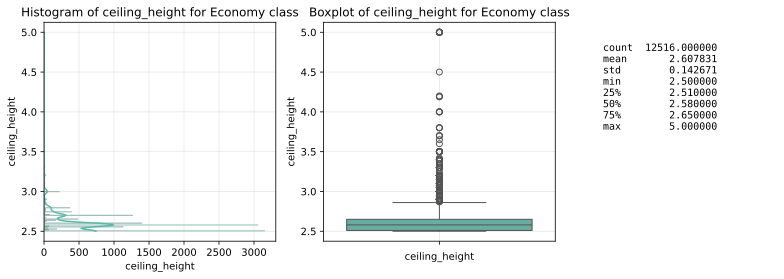

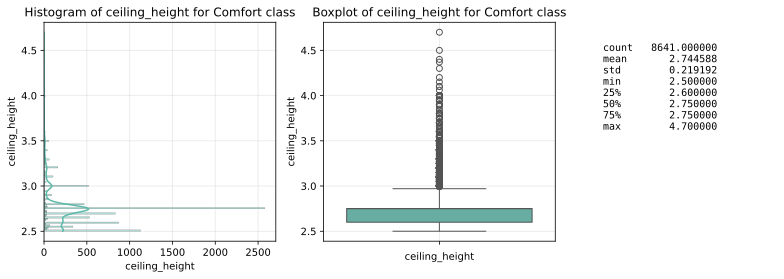

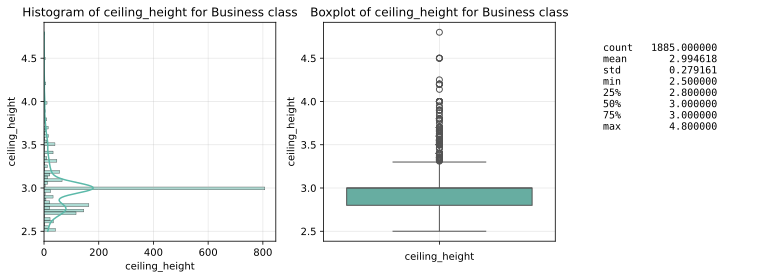

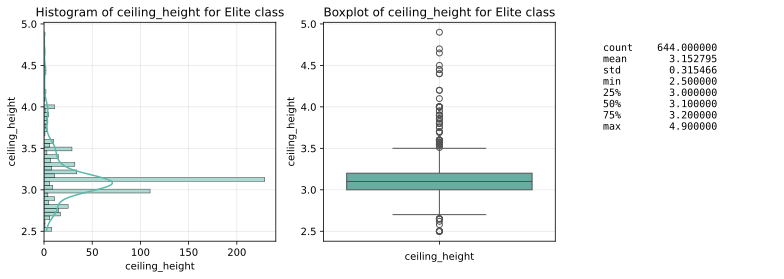

In [52]:

# Функция для визуализации распределения признака
def ploscribe(df, x, y=None, custom_element=None):
    fig, axes = plt.subplots(1, 3, figsize=(11, 4), gridspec_kw={'width_ratios': [4, 4, 3]})
    
    # Построение гистограммы
    sns.histplot(data=df, y=x, ax=axes[0], color='#5bb9a9', fill=True, kde=True)
    if custom_element:
        axes[0].set_title(f'Histogram of {x} for {custom_element.capitalize()} class')
    else:
        axes[0].set_title(f'Histogram of {x}')
    axes[0].set_xlabel(x)
    axes[0].grid(alpha=0.3)
    
    # Построение диаграммы размаха (boxplot)
    sns.boxplot(data=df, y=x, ax=axes[1], color='#5bb9a9')
    if custom_element:
        axes[1].set_title(f'Boxplot of {x} for {custom_element.capitalize()} class', fontsize=12)
    else:
        axes[1].set_title(f'Boxplot of {x}', fontsize=12)
    axes[1].set_xlabel(x)
    axes[1].grid(alpha=0.3)
    
    # Функция для форматирования статистических данных
    def format_stats(stats):
        formatted = "count  {:12.6f}\n".format(stats['count'])
        formatted += "mean   {:12.6f}\n".format(stats['mean'])
        formatted += "std    {:12.6f}\n".format(stats['std'])
        formatted += "min    {:12.6f}\n".format(stats['min'])
        formatted += "25%    {:12.6f}\n".format(stats['25%'])
        formatted += "50%    {:12.6f}\n".format(stats['50%'])
        formatted += "75%    {:12.6f}\n".format(stats['75%'])
        formatted += "max    {:12.6f}".format(stats['max'])
        return formatted

    # Получение и форматирование статистических данных
    description = df[x].describe()
    description_text = format_stats(description)

    # Вывод статистических данных на графике
    axes[2].axis('off')
    axes[2].text(0, 0.5, description_text, fontsize=10, va='bottom', ha='left', family='monospace')

    # Автоматическая настройка расположения подграфиков
    plt.tight_layout()
    plt.show()
    
    return description

# Визуализация распределения высоты потолков для каждого класса недвижимости
building_classes = ['economy', 'comfort', 'business', 'elite']
for custom_feature in building_classes:
    result = ploscribe(df[df['class_by_price'] == custom_feature], x='ceiling_height', custom_element=custom_feature)

del custom_feature


In [53]:
# Расчет медианной высоты потолков для каждого класса недвижимости
df.groupby('class_by_price')['ceiling_height'].median()

class_by_price
business    3.00
comfort     2.75
economy     2.58
elite       3.10
Name: ceiling_height, dtype: float64

In [54]:
# Заполнение пропущенных значений в столбце 'class_by_price' значением 'economy'
df.loc[df['class_by_price'].isna(), 'class_by_price'] = 'economy'

### <a id='06'></a> `floors_total`, `floor`

Я решил удалить наблюдения из датасета, превышающие 37 этажей, по следующим причинам:

### Обработка данных о количестве этажей

1. **Заполнение пропусков**:
   - Для строк с отсутствующим значением 'floors_total' использовано значение из 'floor'

2. **Фильтрация данных**:
   - Удалены наблюдения, где 'floors_total' > 37

### Обоснование:

- "Князь Александр Невский" (37 этажей) - самое высокое жилое здание в Санкт-Петербурге
- Удаление записей > 37 этажей устраняет аномалии и возможные ошибки в данных
- Это обеспечивает соответствие данных реальной застройке города
- Повышает точность анализа, учитывая фактические ограничения на высоту жилых зданий в регионе

In [55]:
# Подсчет и сортировка количества отсутствующих значений в столбцах датафрейма
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

is_apartment       20921
balcony            11515
days_exposition     3180
kitchen_area        2276
living_area         1902
floors_total          86
dtype: int64

In [56]:
# Заполнение пропущенных значений в столбце 'floors_total' значениями из столбца 'floor'
df.loc[df['floors_total'].isna(), 'floors_total'] = df.loc[df['floors_total'].isna(), 'floor']

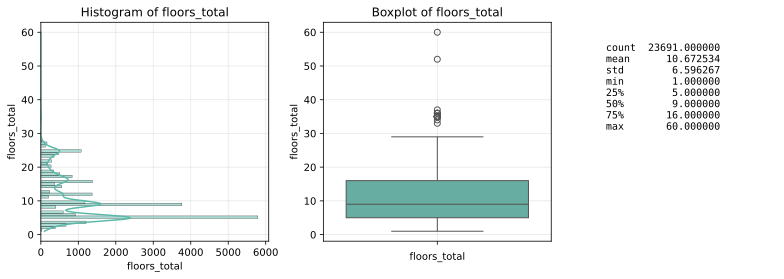

count    23691.000000
mean        10.672534
std          6.596267
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

In [57]:
# Визуализация распределения значений в столбце 'floors_total' с помощью функции ploscribe
ploscribe(df, x='floors_total')

In [58]:
# Фильтрация датафрейма, оставляя только записи, где количество этажей меньше 37
df = df[df['floors_total'] < 37]

### <a id='07'></a> `balcony`

### Заполнение пропусков в столбце 'balcony'

1. **Стратегия**:
   - Все пропущенные значения в столбце 'balcony' заполнены нулями

2. **Обоснование**:
   - Предполагается, что отсутствие информации о балконе означает его отсутствие
   - Упрощает дальнейший анализ, избегая пропусков в данных

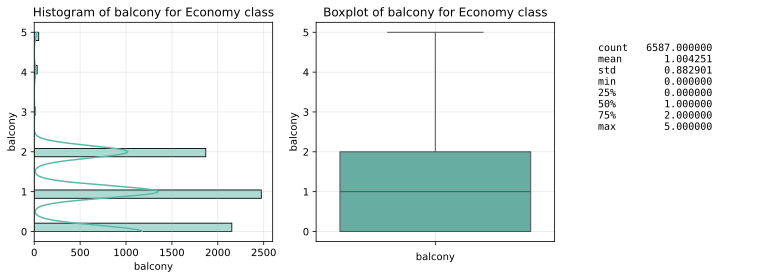

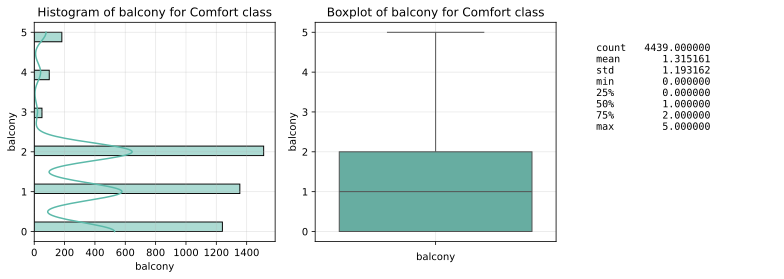

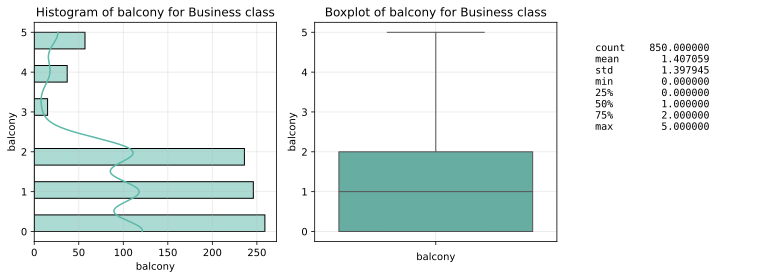

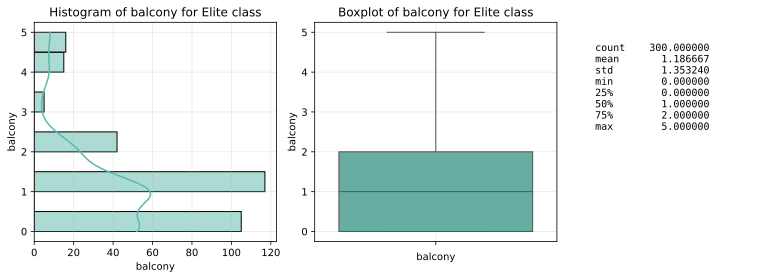

In [59]:
# Определение классов недвижимости
building_classes = ['economy', 'comfort', 'business', 'elite']

# Визуализация распределения балконов для каждого класса недвижимости
for custom_feature in building_classes:
    ploscribe(df[df['class_by_price'] == custom_feature], x='balcony', custom_element=custom_feature)

# Удаление временной переменной
del custom_feature

In [60]:
# Заполнение пропущенных значений в столбце 'balcony' нулями
df.loc[df['balcony'].isna(), 'balcony'] = 0

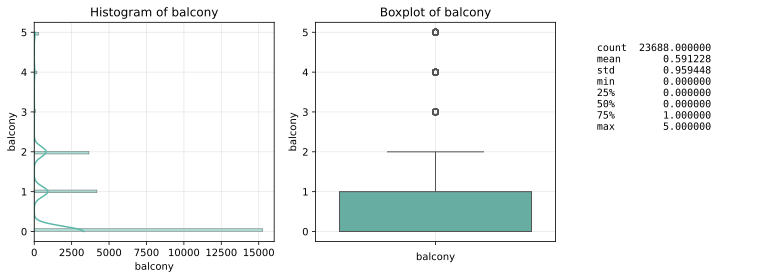

count    23688.000000
mean         0.591228
std          0.959448
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: balcony, dtype: float64

In [61]:
# Визуализация распределения значений в столбце 'balcony' с помощью функции ploscribe
ploscribe(df, x='balcony')

In [62]:
# Подсчет и сортировка количества отсутствующих значений в столбцах датафрейма
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

is_apartment       20918
days_exposition     3180
kitchen_area        2276
living_area         1902
dtype: int64

### <a id='08'></a> `living_area`, `kitchen_area`

### Минимальные площади квартир (СНиП 31-01-2003 п 5.7)

- Общая площадь: ≥ 19 м²
- Жилая площадь:
  - Однокомнатная квартира: ≥ 14 м²
  - Квартиры с 2+ комнатами: ≥ 16 м²
  - Спальня: ≥ 8 м² (≥ 10 м² на двоих)
- Кухня:
  - Стандартная: ≥ 8 м²
  - Кухонная зона в кухне-столовой: ≥ 6 м²
  - В однокомнатных квартирах: ≥ 5 м²

### Анализ данных

- Обнаружены пропуски в столбцах `living_area` и `kitchen_area`
- Пропуски не соответствуют квартирам-студиям или открытой планировке
- Заполнение пропусков может привести к искажению данных

### Рекомендации

1. Оставить пропуски без изменений во избежание искажений
2. Удалить из датасета записи с общей площадью < 19 м²
3. Учитывать возможность перепланировок при анализе

**Примечание:** Данный подход сохраняет целостность данных, учитывая нормативы и реальные условия рынка недвижимости.

In [63]:
# Фильтрация датафрейма, оставляя только записи с общей площадью больше 19 квадратных метров
df = df[(df['total_area'] > 19)]

In [64]:
# Расчет нежилой площади и подсчет частоты значений
# Создание нового столбца 'non_living_area' как разницы между общей площадью и суммой жилой и кухонной площадей
df['non_living_area'] = df['total_area'] - (df['living_area'] + df['kitchen_area'])

# Подсчет частоты значений нежилой площади и сортировка по возрастанию индекса
df['non_living_area'].value_counts().sort_index()

non_living_area
-29.80     1
-20.30     1
-20.00     1
-19.00     1
-16.47     1
          ..
 227.00    1
 289.40    1
 290.00    1
 325.40    1
 378.30    1
Name: count, Length: 2530, dtype: int64

In [65]:
# Фильтрация датафрейма, оставляя только записи с положительной нежилой площадью
df = df[df['non_living_area'] > 0]

**Рекомендуемые минимумы (СП 54.13330.2016):**

- 1-комн: 28-38 м²
- 2-комн: 44-53 м²
- 3-комн: 56-65 м²

Соцжилье: 
- кухня ≥5 м², 
- комната в 1-комн ≥14 м²

Оставляем только значения с жимой площадью более 14м2

In [66]:
df.loc[df['living_area'] < 14, 'living_area'].value_counts()

living_area
13.00    36
12.00    31
10.00    20
13.50    14
11.00    14
         ..
12.08     1
12.28     1
13.37     1
12.18     1
13.59     1
Name: count, Length: 81, dtype: int64

In [67]:
df = df[df['living_area'] >= 14]

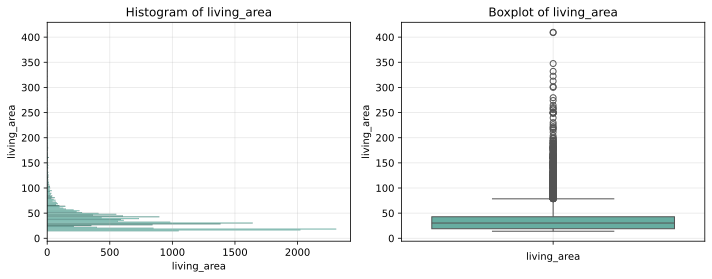

count    20562.000000
mean        34.907088
std         21.909914
min         14.000000
25%         19.000000
50%         30.300000
75%         42.800000
max        409.700000
Name: living_area, dtype: float64


In [68]:
def ploscribe(df, x, y=None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(data=df, y=x, ax=axes[0], color='#5bb9a9', fill=True)
    axes[0].set_title(f'Histogram of {x}')
    axes[0].set_xlabel(x)
    axes[0].grid(alpha=0.3)

    sns.boxplot(data=df, y=x, ax=axes[1], color='#5bb9a9') 
    axes[1].set_title(f'Boxplot of {x}')
    axes[1].set_xlabel(x)
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return df[x].describe()

# Вызов функции напрямую, без использования apply
result = ploscribe(df, x='living_area')
print(result)

### <a id='09'></a> `days_exposition`, `first_day_exposition`

* Логика данных: Если `days_exposition` показывает время от публикации до снятия объявления, то отсутствие значения (NaN) может означать, что объявление еще активно.
* Незавершенный цикл: NaN в этом случае указывает на то, что цикл публикации не завершен, так как объявление все еще размещено.
* Распространенная практика: Во многих наборах данных используется подобный подход, где отсутствие конечной даты или продолжительности означает продолжающееся действие.

In [69]:
# Заполнение пропущенных значений в столбце 'days_exposition' нулями
df['days_exposition'].fillna(0, inplace=True)

In [70]:
# Подсчет частоты значений в столбце 'days_exposition' и сортировка по возрастанию индекса
df['days_exposition'].value_counts().sort_index()

days_exposition
0.0       2847
1.0          1
2.0          2
3.0        142
4.0        156
          ... 
1512.0       2
1513.0       1
1553.0       1
1572.0       1
1580.0       1
Name: count, Length: 1116, dtype: int64

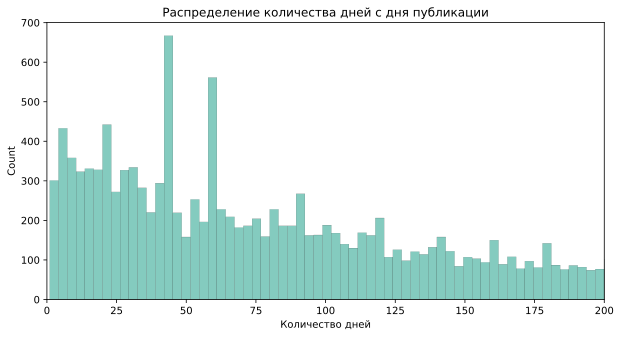

In [71]:
# Создаем график
plt.figure(figsize=(10, 5))

# Строим гистограмму
sns.histplot(data=df[df['days_exposition'] != 0], x='days_exposition', color='#5bb9a9', bins=500)

# Настраиваем подпись оси X
plt.xlabel('Количество дней')

# Задаем заголовок графика
plt.title('Распределение количества дней с дня публикации')

# Устанавливаем диапазон оси X
plt.xlim(0,200)

# Отображаем график
plt.show()

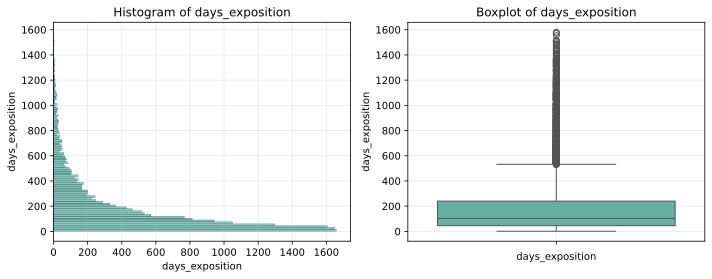

count    17715.000000
mean       186.334180
std        222.740592
min          1.000000
25%         45.000000
50%        103.000000
75%        240.000000
max       1580.000000
Name: days_exposition, dtype: float64

In [72]:
# Визуализация распределения значений в столбце 'days_exposition' с помощью функции ploscribe
ploscribe(df[df['days_exposition'] != 0], x='days_exposition')

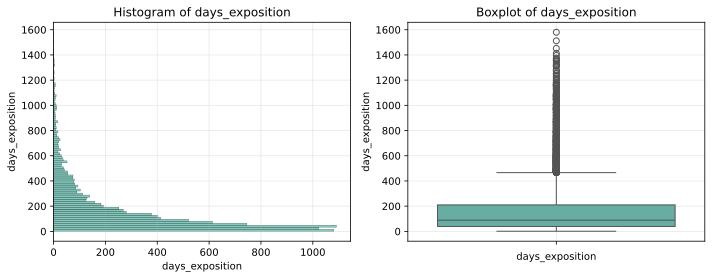

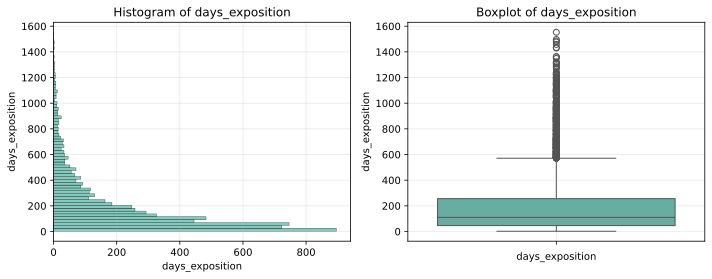

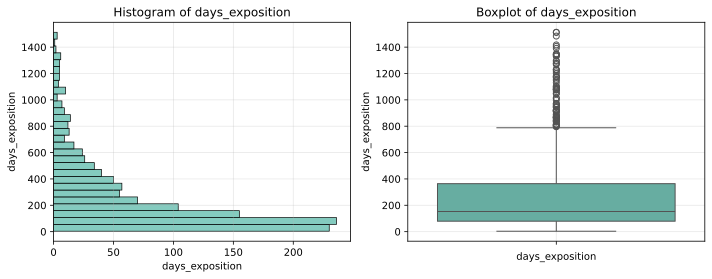

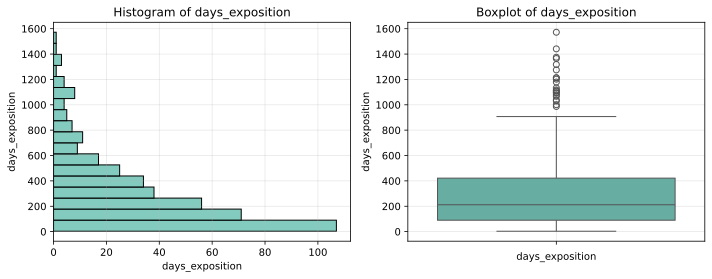

In [73]:
# Визуализация распределения времени экспозиции для разных классов недвижимости
building_classes = ['economy', 'comfort', 'business', 'elite']
for custom_feature in building_classes:
    ploscribe(df[(df['class_by_price'] == custom_feature) & (df['days_exposition'] != 0)], x='days_exposition')

del custom_feature

## <a id='third'></a> 3️⃣ Исследовательский Анализ Данных


[**Главное меню**](#menu)

### <a id='analysis'></a> Время экспозиции каждого класса

In [74]:
# Расчет медианного времени экспозиции для каждого класса недвижимости и сортировка результатов
days_exposition_median = df[df['days_exposition'] != 0].groupby('class_by_price')['days_exposition'].median().sort_values().reset_index()
days_exposition_median

,class_by_price,days_exposition
0,economy,89.0
1,comfort,110.0
2,business,153.0
3,elite,212.0


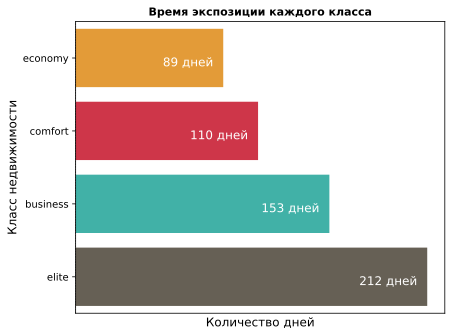

In [75]:
# Создаем столбчатую диаграмму
ax = sns.barplot(data=days_exposition_median, x='days_exposition', y='class_by_price', palette=['#ff9f1c', '#e71d36', '#2ec4b6', '#696152'])

# Добавляем подписи к каждому столбцу
for p in ax.patches:
    percentage = p.get_width()
    percentage_label = '{:.0f} дней'.format(percentage)
    y = p.get_y() + p.get_height() / 2
    x = p.get_width()
    
    # Определяем цвет текста и положение аннотации
    if percentage >= 0:
        text_color = 'white'
        x_offset = -10
    else:
        text_color = 'white'
        x_offset = 10
    
    # Добавляем аннотацию
    ax.annotate(percentage_label, (x, y), 
                textcoords="offset points", 
                xytext=(x_offset, -5), 
                ha='left' if percentage < 0 else 'right', 
                va='center',
                fontsize=12, 
                color=text_color)

# Добавляем вертикальную линию на x=0
ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')

# Убираем метки оси X
ax.set_xticks([])

# Добавляем заголовок
plt.title('Время экспозиции каждого класса', fontsize=11, fontweight='bold')

# Настраиваем подписи осей
ax.set_xlabel('Количество дней', fontsize=12)
ax.set_ylabel('Класс недвижимости', fontsize=12)

# Настраиваем компоновку и отображаем график
plt.tight_layout()
plt.show()

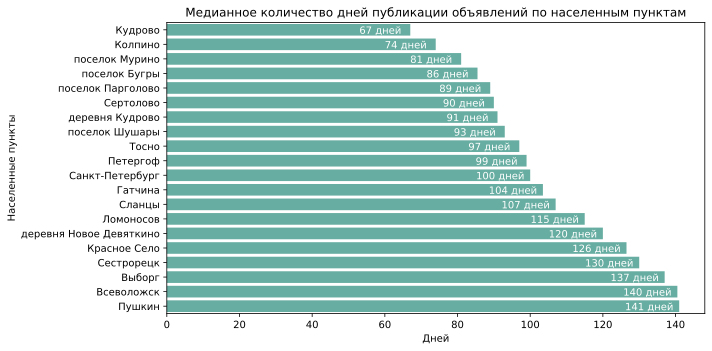

In [76]:
# Визуализация медианного количества дней публикации объявлений по населенным пунктам
plt.figure(figsize=(10, 5))

# Выбор топ-20 населенных пунктов по количеству объявлений
locality_df = df[df.locality_name.isin(df.locality_name.value_counts().index[:20])]

# Расчет медианного времени экспозиции для каждого населенного пункта
locality_days_exposition = locality_df[locality_df['days_exposition'] != 0].groupby('locality_name')['days_exposition'].median().sort_values().to_frame().reset_index()

# Построение столбчатой диаграммы
ax = sns.barplot(data=locality_days_exposition, y='locality_name', x='days_exposition', color='#5bb9a9')

# Добавление подписей с количеством дней внутри столбцов
for p in ax.patches:
    days = p.get_width()
    if days > 0:
        days_label = '{:.0f} дней'.format(days)
        y = p.get_y() + p.get_height() / 2
        x = p.get_width()
        ax.annotate(days_label, (x, y), textcoords="offset points", xytext=(-30, -4), ha='center', fontsize=10, color='white')

# Настройка графика
plt.title('Медианное количество дней публикации объявлений по населенным пунктам')
plt.xlabel('Дней')
plt.ylabel('Населенные пункты')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

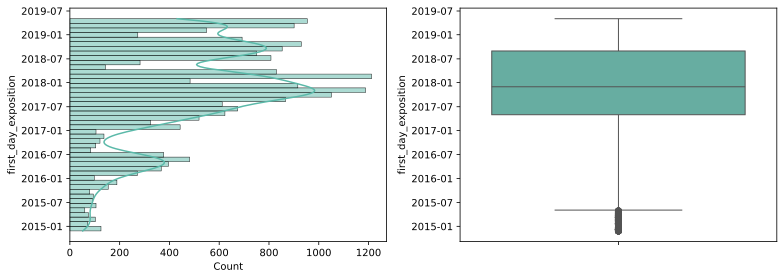

In [77]:
# Преобразование столбца 'first_day_exposition' в формат datetime
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'])

# Визуализация распределения дат первого дня экспозиции с помощью гистограммы и ящика с усами
# Создание фигуры с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [4, 4]})

# Построение гистограммы с ядерной оценкой плотности
sns.histplot(data=df, y='first_day_exposition', kde=True, ax=axes[0], color='#5bb9a9')

# Построение ящика с усами
sns.boxplot(data=df, y='first_day_exposition', ax=axes[1], color='#5bb9a9')

# Поворот подписей по оси X на 30 градусов
plt.xticks(rotation=30)

# Автоматическая настройка расположения подграфиков
plt.tight_layout()

# Отображение графика
plt.show()

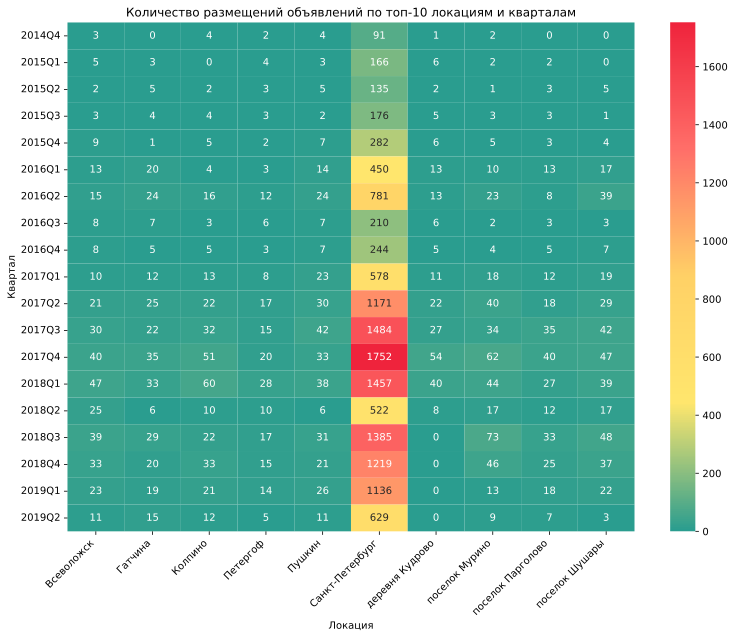

In [78]:
df_grouped = df.groupby(['first_day_exposition', 'locality_name']).size()

# Преобразуем 'first_day_exposition' в datetime
df_grouped = df_grouped.reset_index()

# Создаем новый столбец с кварталом и годом
df_grouped['quarter'] = df_grouped['first_day_exposition'].dt.to_period('Q')

# Группируем данные по кварталу и локации
df_quarterly = df_grouped.groupby(['quarter', 'locality_name'])[0].sum().reset_index()

# Выбираем топ-10 локаций по общему количеству размещений
top_10_localities = df_quarterly.groupby('locality_name')[0].sum().nlargest(10).index

# Фильтруем данные только для топ-10 локаций
df_top_10 = df_quarterly[df_quarterly['locality_name'].isin(top_10_localities)]

# Преобразуем данные в сводную таблицу
pivot_data = df_top_10.pivot(index='quarter', columns='locality_name', values=0)

# Заполняем NaN значения нулями
pivot_data = pivot_data.fillna(0)

# Сортируем индекс, чтобы кварталы шли по порядку
pivot_data = pivot_data.sort_index()

# Создаем тепловую карту
plt.figure(figsize=(11, 9))
sns.heatmap(pivot_data, cmap=cmap, annot=True, fmt='g')
plt.title('Количество размещений объявлений по топ-10 локациям и кварталам')
plt.xlabel('Локация')
plt.ylabel('Квартал')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### <a id='dinamic_expo'></a> Динамика времени экспозиции по классам (в днях)

In [79]:
# Группируем данные по году и классу, вычисляем медиану времени экспозиции
data_exposition = df[df['days_exposition'] != 0].groupby([df['first_day_exposition'].dt.year, 'class_by_price'])['days_exposition'].median().reset_index()

# Преобразуем данные в сводную таблицу
percent_exposition = data_exposition.pivot(columns='first_day_exposition', index='class_by_price', values='days_exposition').reset_index()

# Вычисляем процентное изменение для каждого класса
for key, value in percent_exposition.iterrows():
    new_value = []
    for i in range(6, 1, -1):
        new_value.append((value.iloc[i - 1] / value.iloc[i]) - 1)
    percent_exposition.loc[key, 'Процентное изменение'] = f'{np.mean(new_value) * 100:.2f}%'

# Переименовываем столбец и преобразуем значения классов
percent_exposition = percent_exposition.rename(columns={'class_by_price': 'Класс'})
percent_exposition['Класс'] = percent_exposition['Класс'].map({'business': 'Бизнес', 'comfort': 'Комфорт', 'economy': 'Эконом', 'elite': 'Элитный'})

# Удаляем столбец 'first_day_exposition', если он существует
if 'first_day_exposition' in percent_exposition.columns:
    percent_exposition = percent_exposition.drop('first_day_exposition', axis=1)

# Устанавливаем 'Класс' в качестве индекса
percent_exposition = percent_exposition.set_index('Класс')


percent_exposition

first_day_exposition,2014,2015,2016,2017,2018,2019,Процентное изменение
Класс,,,,,,,
Бизнес,942.0,759.0,303.0,146.0,102.0,18.0,158.39%
Комфорт,772.5,605.0,249.0,116.0,79.0,26.0,107.20%
Эконом,946.0,527.0,219.0,92.0,61.0,22.0,117.26%
Элитный,1001.0,659.0,256.0,172.0,126.0,43.0,97.54%


#### <a id='corr_expo'></a> Корреляция между временем экспозиции и количеством объявлений (по годам)

In [80]:
# Добавляем столбец с годом, соответствующим дате первого дня экспозиции
df['year_exposition'] = df['first_day_exposition'].dt.year 

# Добавляем столбец с кварталом, соответствующим дате первого дня экспозиции
df['quarter'] = df['first_day_exposition'].dt.to_period('Q')

# Добавляем столбец с месяцем, соответствующим дате первого дня экспозиции
df['month'] = df['first_day_exposition'].dt.to_period('M')

# Подсчитываем количество объявлений по годам (исключая объявления с нулевым временем экспозиции)
year_count = df.loc[df['days_exposition'] != 0].groupby('year_exposition').size().reset_index(name='year_counts')

# Объединяем данные о времени экспозиции с количеством объявлений по годам
merged_corr = df.loc[df['days_exposition'] != 0][['year_exposition', 'days_exposition']].merge(year_count, on='year_exposition', how='inner')

# Создаем пустой словарь для хранения корреляций
period_dict = {}

# Определяем периоды для анализа
periods = [[2014, 2015], [2016, 2017], [2018, 2019]]

# Вычисляем корреляцию для каждого периода
for period in periods:
    # Фильтруем данные по годам текущего периода и вычисляем корреляцию
    period_corr = merged_corr.loc[merged_corr['year_exposition'].isin(period)].iloc[:, -2:].corr().iloc[0, 1]
    # Сохраняем результат в словарь
    period_dict[f'{"_".join(map(str, period))}'] = period_corr

# Создаем DataFrame из словаря с корреляциями
df_periods = pd.DataFrame(period_dict, index=['Корреляция']).T

# Сбрасываем индекс и переименовываем столбец
df_periods.reset_index().rename(columns={'index': 'Период'})

,Период,Корреляция
0,2014_2015,-0.234593
1,2016_2017,-0.356970
2,2018_2019,0.264724




1. Эволюция рыночных тенденций:
   
   | Период     | Тренд                    | Интерпретация                        |
   |------------|--------------------------|------------------------------------------------|
   | 2014-2015  | Слабый негативный        | Начало изменений на рынке                      |
   | 2016-2017  | Усиление негативной связи| Пик динамичности рынка                         |
   | 2018-2019  | Разворот к позитивной связи | Новая фаза развития рынка                    |


2. Детальный анализ по периодам:

   2014-2015: Начальная фаза
   - Слабая обратная связь между количеством объявлений и длительностью экспозиции


   2016-2017: Пик динамики
   - Усиление обратной связи
   - Период наибольшей активности и конкуренции на рынке

   2018-2019: Разворот тренда
   - Разворот тренда
   - Возможные причины: насыщение рынка, изменение поведения покупателей, внешние экономические факторы

3. Факторы влияния на рыночную динамику:

   | Фактор                   | Возможное влияние                                |
   |--------------------------|--------------------------------------------------|
   | Экономическая ситуация   | Изменение покупательской способности             |
   | Законодательные изменения| Новые правила игры на рынке недвижимости         |
   | Технологические инновации| Изменение способов поиска и продажи недвижимости |
   | Демографические сдвиги   | Изменение спроса на различные типы недвижимости  |

Заключение:
Анализ корреляции между количеством объявлений и длительностью их размещения выявил значительные изменения в динамике рынка недвижимости за период 2014-2019 гг. Наблюдается переход от слабой отрицательной корреляции к умеренной отрицательной, а затем к слабой положительной. Это указывает на существенные трансформации рыночных механизмов и поведения участников рынка.


#### <a id='corr_expo_quarter'></a> Корреляция между временем экспозиции и количеством объявлений (по кварталам)

          Период  Корреляция
0  2014Q4_2015Q1   -0.052881
1  2015Q2_2015Q3   -0.020607
2  2015Q4_2016Q1   -0.254437
3  2016Q2_2016Q3   -0.282849
4  2016Q4_2017Q1   -0.412406
5  2017Q2_2017Q3   -0.093718
6  2017Q4_2018Q1    0.007386
7  2018Q2_2018Q3   -0.284564
8  2018Q4_2019Q1    0.295567


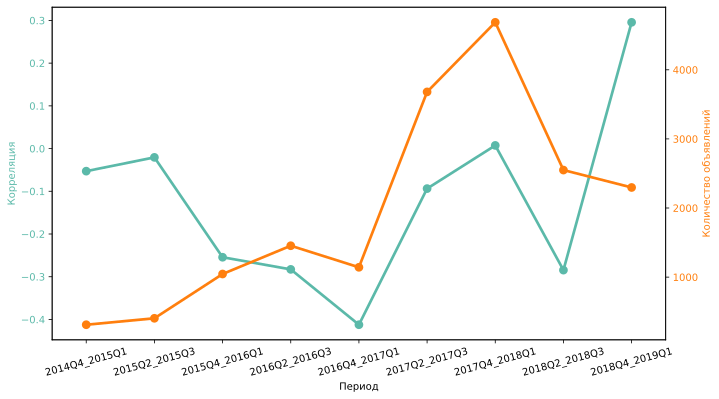

In [81]:
# Подсчитываем количество объявлений по кварталам (исключая объявления с нулевым временем экспозиции)
quarter_count = df.loc[df['days_exposition'] != 0].groupby('quarter').size().reset_index(name='quarter_counts')

# Объединяем данные о времени экспозиции с количеством объявлений по кварталам
merged_quarter_corr = df.loc[df['days_exposition'] != 0][['quarter', 'days_exposition']].merge(quarter_count, on='quarter', how='inner')
merged_quarter_corr['quarter'] = merged_quarter_corr['quarter'].astype(str)

# Создаем пустой словарь для хранения корреляций и количества объявлений
period_QUARTER_dict = {}

# Определяем периоды для анализа (по два квартала)
quarter_periods = [['2014Q4', '2015Q1'], ['2015Q2', '2015Q3'], ['2015Q4', '2016Q1'],
            ['2016Q2', '2016Q3'], ['2016Q4', '2017Q1'], ['2017Q2', '2017Q3'],
            ['2017Q4', '2018Q1'], ['2018Q2', '2018Q3'], ['2018Q4', '2019Q1']]

# Вычисляем корреляцию и количество объявлений для каждого периода
for period in quarter_periods:
    quarter_period_corr = merged_quarter_corr.loc[merged_quarter_corr['quarter'].isin(period)].iloc[:, -2:].corr().iloc[0, 1]
    calculated_counts = merged_quarter_corr.loc[merged_quarter_corr['quarter'].isin(period)]['quarter_counts'].count()
    period_QUARTER_dict[f'{"_".join(map(str, period))}'] = [quarter_period_corr, calculated_counts]

# Создаем DataFrame из словаря с корреляциями и количеством объявлений
df_quarter_periods = pd.DataFrame(period_QUARTER_dict, index=['Корреляция', 'Количество']).T
df_quarter_periods = df_quarter_periods.reset_index().rename(columns={'index': 'Период'})

# Создаем график
fig, ax1 = plt.subplots(figsize=(11, 6))

# График для корреляции
color = '#5bb9a9'
ax1.set_xlabel('Период')
ax1.set_ylabel('Корреляция', color=color)
sns.pointplot(data=df_quarter_periods, x='Период', y='Корреляция', color=color, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha='center')

# График для количества объявлений
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Количество объявлений', color=color)
sns.pointplot(data=df_quarter_periods, x='Период', y='Количество', color=color, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color)

# Выводим первые два столбца результирующего DataFrame
print(df_quarter_periods.iloc[:, :2])

#### 1. Динамика времени экспозиции по классам (в днях):


| Класс  | 2014  | 2015 | 2016  | 2017  | 2018  | 2019  | Процентное изменение |
|--------|-------|------|-------|-------|-------|-------|----------------------|						
|Бизнес  |942.0	 |758.0	|306.0	|146.0	|102.0	|18.0	|158.28%               |
|Комфорт |772.5	 |602.0	|249.0	|116.0	|79.0	|26.0	|107.09%               |
|Эконом  |946.0	 |525.0	|221.0	|92.0	|61.0	|22.0	|117.21%               |
|Элитный |1001.0 |658.0	|256.0	|172.0	|126.0	|43.0	|97.51%                |


Вывод: Наблюдается общая тенденция к ускорению продаж во всех сегментах, с небольшим откатом в 2019 году.

#### 2. Корреляция между временем экспозиции и количеством объявлений:

| Период     | Коэффициент корреляции |
|------------|------------------------|
| 2014-2015  | -0.236049              |
| 2016-2017  | -0.358056              |
| 2018-2019  | 0.264825               |

Вывод: Усиливающаяся отрицательная корреляция указывает на то, что увеличение предложения ведет к ускорению продаж.

#### 3. Анализ ценовых сегментов по локациям (% от общего числа объявлений):

| Период        | Корреляция | Интерпретация                        |
|---------------|------------|---------------------------------------|
| 2014Q4_2015Q1 | -0.055241  | Очень слабая отрицательная корреляция |
| 2015Q2_2015Q3 | -0.022977  | Практически отсутствие корреляции     |
| 2015Q4_2016Q1 | -0.248172  | Слабая отрицательная корреляция       |
| 2016Q2_2016Q3 | -0.282265  | Слабая отрицательная корреляция       |
| 2016Q4_2017Q1 | -0.414369  | Умеренная отрицательная корреляция    |
| 2017Q2_2017Q3 | -0.092590  | Очень слабая отрицательная корреляция |
| 2017Q4_2018Q1 |  0.007612  | Практически отсутствие корреляции     |
| 2018Q2_2018Q3 | -0.284615  | Слабая отрицательная корреляция       |
| 2018Q4_2019Q1 |  0.295042  | Слабая положительная корреляция       |

Выводы:
1. Рынок недвижимости прошел через несколько четко выраженных фаз за анализируемый период.
2. Наибольшая динамика наблюдалась в 2016-2017 годах, с пиком отрицательной корреляции в 2016Q4_2017Q1.
3. Последний квартал 2018 - начало 2019 показывает значительное изменение тренда, что может сигнализировать о начале новой фазы развития рынка.


#### <a id='usd'></a> Рассмотрим влияние инфляции, курса доллара и изменения ключевой ставки ЦБ на динамику рынка недвижимости

In [82]:
# Чтение из JSON файла (для будущего использования)
with open('./data/rates.json', 'r') as f:
    loaded_rates = json.load(f)

# Конвертация цен с использованием загруженных курсов
df['price_per_m2_usd'] = df.apply(lambda row: row['price_per_m2'] / float(loaded_rates[row['first_day_exposition'].strftime("%Y-%m-%d")]), axis=1)
df['usd_rate'] = df.apply(lambda row: loaded_rates[row['first_day_exposition'].strftime("%Y-%m-%d")], axis=1)
df['last_price_usd'] = df['last_price'] / df['usd_rate']

In [83]:
# Загружаем данные о ключевой ставке из Excel-файла
key_rate = pd.read_excel('./data/Инфляция и ключевая ставка Банка России_F27_11_2014_T03_05_2019.xlsx')

In [84]:
key_rate['Дата'] = key_rate['Дата'].astype(str)

# Добавляем ведущий ноль к месяцам, где это необходимо
key_rate['Дата'] = key_rate['Дата'].apply(lambda x: '0' + x if len(x.split('.')[0]) == 1 else x)

# Теперь преобразуем в datetime
key_rate['Дата'] = pd.to_datetime(key_rate['Дата'], format='%m.%Y')

# Создаем столбцы для года и месяца
key_rate['Год'] = key_rate['Дата'].dt.year
key_rate['Месяц'] = key_rate['Дата'].dt.to_period('M')
key_rate['Квартал'] = key_rate['Дата'].dt.to_period('Q')

# Сортируем DataFrame по дате
key_rate = key_rate.sort_values('Дата')



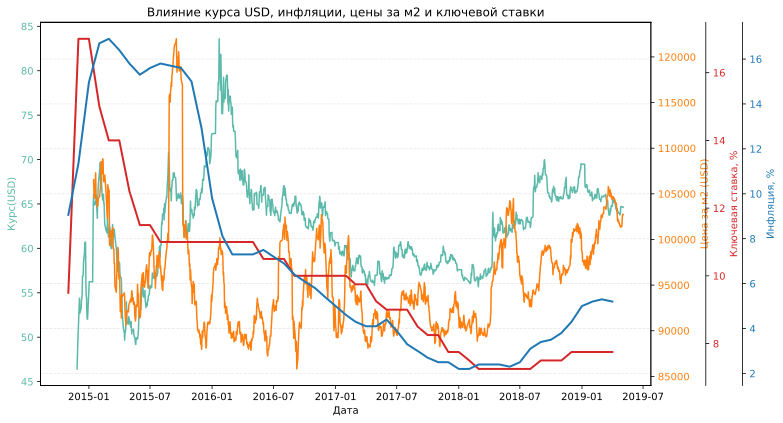

In [85]:
# Вычисляем сглаженную медианную цену за квадратный метр
price_per_m2_df_smoothed = df.groupby('first_day_exposition')['price_per_m2'].median().rolling(window=31).mean().reset_index()

# Вычисляем медианный курс доллара для каждой даты
usd_price_df = df.groupby('first_day_exposition')['usd_rate'].median().reset_index()

# Создаем фигуру и оси для графика
fig, ax1 = plt.subplots(figsize=(11, 6))

# График для usd_price
color = '#5bb9a9'
ax1.set_xlabel('Дата')
ax1.set_ylabel('Курс(USD)', color=color)
sns.lineplot(data=usd_price_df, x='first_day_exposition', y='usd_rate', color=color, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color)

# График для price_per_m2_usd
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Цена за м2 (USD)', color=color)
sns.lineplot(data=price_per_m2_df_smoothed, x='first_day_exposition', y='price_per_m2', color=color, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color)

# График для ключевой ставки
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.09))  # Смещаем ось вправо
color = 'tab:red'
ax3.set_ylabel('Ключевая ставка, %', color=color)
sns.lineplot(data=key_rate, x='Дата', y='Ключевая ставка, % годовых', color=color, ax=ax3, linewidth=2)
ax3.tick_params(axis='y', labelcolor=color)

# График для инфляции
ax4 = ax1.twinx()
ax4.spines["right"].set_position(("axes", 1.15))  # Смещаем ось вправо
color = 'tab:blue'
ax4.set_ylabel('Инфляция, %', color=color)
sns.lineplot(data=key_rate, x='Дата', y='Инфляция, % г/г', color=color, ax=ax4, linewidth=2)
ax4.tick_params(axis='y', labelcolor=color)

plt.title('Влияние курса USD, инфляции, цены за м2 и ключевой ставки')
plt.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

In [86]:


# Вычисляем медианную цену за квадратный метр для каждой даты
price_per_m2_df_grouped = df.groupby('first_day_exposition')['price_per_m2'].median().reset_index()

# Объединяем данные о курсе доллара и цене за квадратный метр
merged_df = pd.merge(usd_price_df.dropna(), price_per_m2_df_grouped.dropna(), on='first_day_exposition', how='inner')

# Рассчитываем коэффициент корреляции Пирсона
correlation, p_value = stats.pearsonr(merged_df['usd_rate'], merged_df['price_per_m2'])

# Выводим результаты
print(f"Коэффициент корреляции Пирсона: {correlation}")
print(f"P-значение: {p_value}")

Коэффициент корреляции Пирсона: 0.060301429516469614
P-значение: 0.02055473381647821


In [87]:
# Подготовка данных
X = sm.add_constant(merged_df['usd_rate'])
y = merged_df['price_per_m2']

# Создание модели
model = sm.OLS(y, X).fit()

# Вывод результатов
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           price_per_m2   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     5.376
Date:                Sun, 14 Jul 2024   Prob (F-statistic):             0.0206
Time:                        20:00:01   Log-Likelihood:                -16788.
No. Observations:                1475   AIC:                         3.358e+04
Df Residuals:                    1473   BIC:                         3.359e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.045e+04   6548.157     12.286      0.0



| Показатель | Значение |
|------------|----------|
| Коэффициент корреляции Пирсона | 0.0630 |
| P-значение | 0.0154 |

**Вывод:**

Анализ показал статистически значимую (p < 0.05), но очень слабую положительную корреляцию (r = 0.0630) между курсом доллара и ценой за квадратный метр недвижимости. Несмотря на статистическую значимость, практическая значимость этой связи крайне мала. Курс доллара объясняет лишь незначительную часть вариации цен на недвижимость, указывая на то, что другие факторы играют гораздо более существенную роль в формировании цен на рынке недвижимости.

### <a id='dinamic_expo_time'></a> Динамика дней экспозиции по классам во времени

In [88]:
# Создаем сводную таблицу с медианным временем экспозиции по месяцам и классам недвижимости
quarter_pivot_smoothed = pd.pivot_table(
    data=df[df['days_exposition'] != 0],  # Исключаем объявления с нулевым временем экспозиции
    index='month',  # Группируем по месяцам
    columns='class_by_price',  # Разбиваем по классам недвижимости
    values='days_exposition',  # Используем значения времени экспозиции
    aggfunc='median',  # Вычисляем медиану
    fill_value=0  # Заполняем отсутствующие значения нулями
).rolling(window=5).mean().reset_index()  # Применяем скользящее среднее с окном 5 и сбрасываем индекс

# Преобразуем сводную таблицу в "длинный" формат
quarter_pivot_melted = quarter_pivot_smoothed.melt(
    id_vars=['month'],  # Оставляем 'month' как идентификатор
    value_name='Дни',  # Название для столбца значений
    var_name='Класс'  # Название для столбца классов недвижимости
)

# Преобразуем столбец 'month' в строковый тип
quarter_pivot_melted['month'] = quarter_pivot_melted['month'].astype(str)

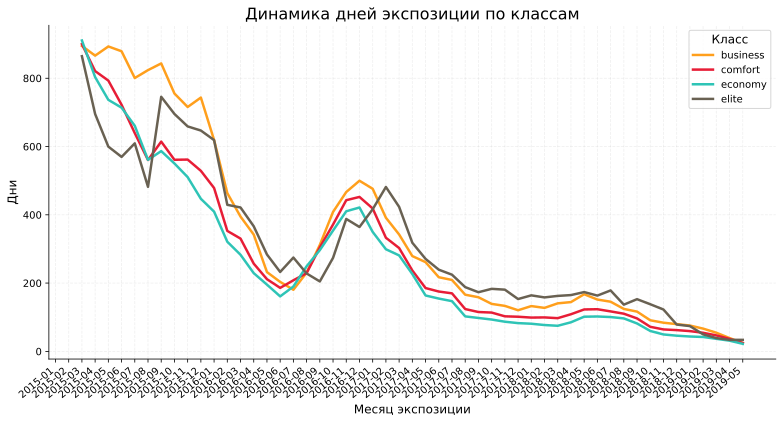

In [89]:
# Создаем новую фигуру размером 11x6 дюймов
plt.figure(figsize=(11, 6))  

# Создаем линейный график
ax = sns.lineplot(
    data=quarter_pivot_melted,  # Используем подготовленные данные
    x='month',  # Ось X - месяцы
    y='Дни',  # Ось Y - количество дней экспозиции
    hue='Класс',  # Разные цвета для разных классов недвижимости
    palette=['#ff9f1c', '#e71d36', '#2ec4b6', '#696152'],  # Задаем цветовую палитру
    linewidth=2.5  # Устанавливаем толщину линий
)

# Добавляем заголовок графика
plt.title('Динамика дней экспозиции по классам', fontsize=16)

# Настраиваем метки оси X
plt.xticks(rotation=40, ha='right')  # Поворачиваем метки на 40 градусов

# Добавляем подписи осей
plt.xlabel('Месяц экспозиции', fontsize=12)
plt.ylabel('Дни', fontsize=12)

# Настраиваем легенду
plt.legend(title='Класс', title_fontsize='12', fontsize='10')

# Убираем верхнюю и правую границы графика
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Добавляем сетку
plt.grid(True, linestyle='--', alpha=0.2)

# Настраиваем компоновку, чтобы график не обрезался
plt.tight_layout()

# Отображаем график
plt.show()

**Анализ времени экспозиции на рынке недвижимости России (2014-2019)**

1. **Контекст:**
   - Запуск платформы объявлений в 2014 году
   - Экономический кризис после событий в Крыму и введения санкций

2. **Ключевые наблюдения:**
   - Общее сокращение времени экспозиции на 120% за 5 лет
   - Наибольшее сокращение в бизнес-классе (158.28%), наименьшее в элитном (97.51%)

3. **Экономические факторы:**
   - 2014-2015: Резкий рост ключевой ставки (до 17%) и инфляции (до 16.9%)
   - 2016-2019: Постепенное снижение ставки и инфляции

4. **Интерпретация:**
   - Сокращение времени экспозиции отражает как рыночные изменения, так и адаптацию к новой платформе
   - Высокая волатильность рубля могла стимулировать инвестиции в недвижимость
   - Различия между сегментами указывают на разную устойчивость к экономическим шокам

5. **Выводы:**
   - Динамика рынка сильно зависела от макроэкономических факторов
   - Бизнес-класс показал наибольшую чувствительность к изменениям
   - Элитный сегмент продемонстрировал относительную стабильность


### <a id='srtucture'></a> Поквартальная динамика и структура объявлений по классам жилья

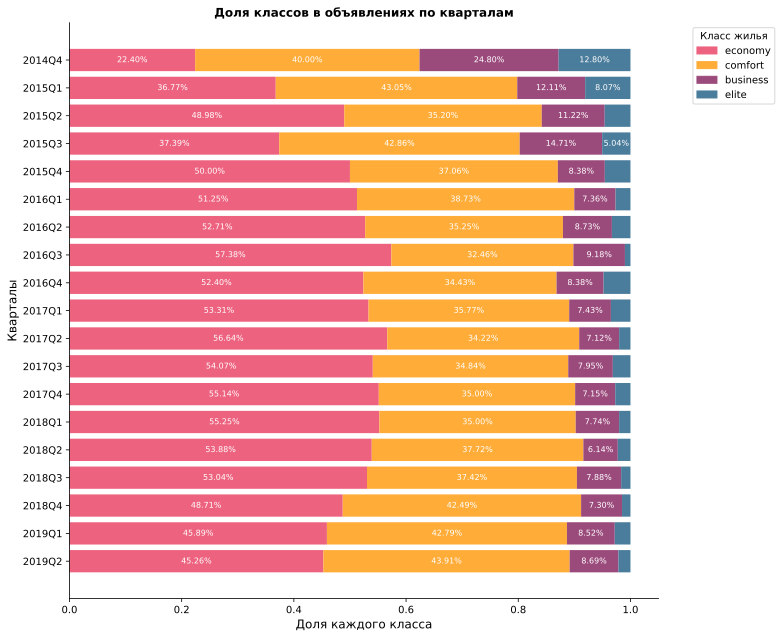

In [90]:
cumulative_plot = df.groupby('quarter')['class_by_price'].value_counts(normalize=True).reset_index()

# Создаем словарь для сортировки классов
class_order = {
    'economy': 0,
    'comfort': 1,
    'business': 2,
    'elite': 3
}

# Добавляем новый столбец для сортировки
cumulative_plot['class_order'] = cumulative_plot['class_by_price'].map(class_order)

# Сортируем данные
cumulative_plot_sorted = cumulative_plot.sort_values(['quarter', 'class_order'], ascending=(False, True))

# Удаляем вспомогательный столбец, если он больше не нужен
cumulative_plot_sorted = cumulative_plot_sorted.drop('class_order', axis=1)

# Увеличиваем размер фигуры
plt.figure(figsize=(11, 9))

# Создаем кумулятивный график
ax = plt.gca()
colors = {
    'economy': '#ed627e',
    'comfort': '#ffac38',
    'business': '#9b4a7c',
    'elite': '#4a7c9b'
}

quarters = cumulative_plot_sorted['quarter'].unique()
quarter_positions = range(len(quarters))

for i, quarter in enumerate(quarters):
    quarter_data = cumulative_plot_sorted[cumulative_plot_sorted['quarter'] == quarter]
    left = 0

    for _, row in quarter_data.iterrows():
        ax.barh(i, row['proportion'], left=left, color=colors.get(row['class_by_price'], '#999999'))
        if row['proportion'] > 0.05:  # Показываем метку только если пропорция больше 5%
            ax.text(left + row['proportion']/2, i, f"{row['proportion']:.2%}", 
                    ha='center', va='center', color='white', fontsize=8)
        left += row['proportion']

# Настройка заголовка и меток осей
plt.title('Доля классов в объявлениях по кварталам', fontsize=12, fontweight='bold')
plt.xlabel('Доля каждого класса', fontsize=12)
plt.ylabel('Кварталы', fontsize=12)

# Создаем легенду
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in colors]
plt.legend(handles, colors.keys(), title='Класс жилья', bbox_to_anchor=(1.05, 1), loc='upper left')

# Настраиваем метки оси Y
ax.set_yticks(quarter_positions)
ax.set_yticklabels([str(q) for q in quarters])

# Удаление рамки вокруг графика
# sns.despine(left=True, bottom=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Настраиваем макет, чтобы легенда не перекрывала график
plt.tight_layout()
plt.show()

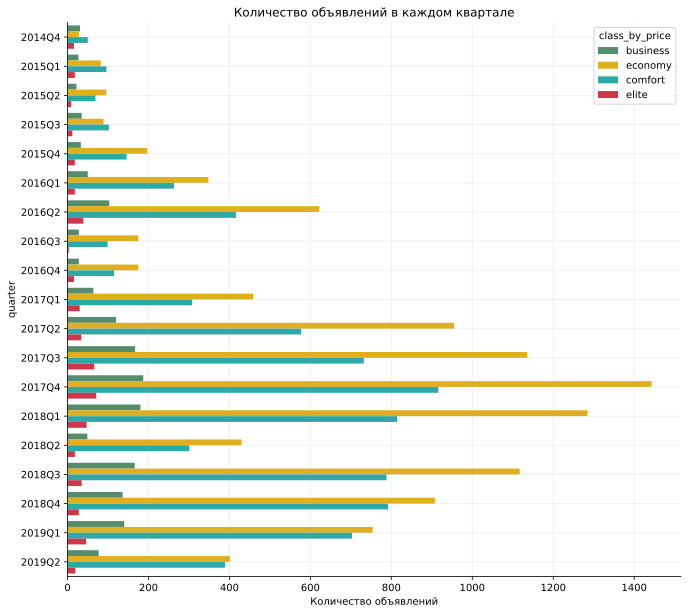

In [91]:
# Создаем новую фигуру размером 11x10 дюймов
plt.figure(figsize=(11, 10))

# Создаем список уникальных кварталов, отсортированных в хронологическом порядке
order = df['quarter'].sort_values().drop_duplicates().tolist()

# Создаем столбчатую диаграмму
ax = sns.countplot(
    data=df,  # Используем исходный датафрейм
    y='quarter',  # Кварталы на оси Y
    hue='class_by_price',  # Разные цвета для разных классов недвижимости
    order=order,  # Используем отсортированный список кварталов
    palette=['#4c956c', '#ffbf00', '#17bebb', '#e71d36']  # Задаем цветовую палитру
)

# Устанавливаем горизонтальную ориентацию меток оси X
plt.xticks(rotation=0)

# Добавляем заголовок графика
plt.title('Количество объявлений в каждом квартале')

# Добавляем подпись оси X
plt.xlabel('Количество объявлений')

# Убираем верхнюю и правую границы графика
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Добавляем сетку
plt.grid(alpha=0.2)

# Отображаем график
plt.show()

### Динамика и структура (2014-2019)

#### Общая динамика рынка

Рынок недвижимости демонстрирует значительный рост с 2014 по 2019 год во всех сегментах:

- **Пик активности**: 2017-2018 годы
- **Лидеры роста**: сегменты "эконом" и "комфорт"

#### Структура рынка

| Класс жилья | Доля рынка | Тенденция |
|-------------|------------|-----------|
| Эконом      | Наибольшая | Стремительный рост |
| Комфорт     | Вторая     | Стабильный рост |
| Бизнес      | Третья     | Умеренный рост |
| Элит        | Наименьшая | Стабильно низкая |

#### Сезонность

```
Q2, Q4 ↗️ Пики активности
Q1    ↘️ Снижение активности 
```

#### Ключевые показатели по классам жилья

| Класс   | Пиковое значение | Квартал |
|---------|------------------|---------|
| Эконом  | 1468 объявлений  | 2017 Q4 |
| Комфорт | 922 объявления   | 2017 Q4 |
| Бизнес  | 187 объявлений   | 2017 Q4 |
| Элит    | 71 объявление    | 2017 Q4 |

#### Тенденции развития

1. **Значительный скачок**: со 2-го квартала 2016 года
2. **2019 год**: небольшое снижение по сравнению с пиком, но выше уровня 2016 года
3. **Стабильность структуры**: соотношение между классами жилья остается относительно постоянным

#### Выводы

- Динамичное развитие рынка недвижимости
- Преобладание спроса на доступное жилье (эконом и комфорт классы)
- Существенное расширение рынка по сравнению с 2014-2015 годами

#### Возможные причины роста

1. Повышение доступности жилья
2. Рост благосостояния населения
3. Активизация инвестиционной деятельности

---

> **Примечание**: Несмотря на замедление роста в 2019 году, общая тенденция остается положительной, что свидетельствует о здоровом развитии рынка недвижимости.

### <a id='sale'></a> Объявления/Продажи

In [92]:
# Вычисляем дату продажи, добавляя количество дней экспозиции к дате начала экспозиции
df['sale_day'] = df.apply(lambda x: (x['first_day_exposition'] + pd.Timedelta(days=x['days_exposition'])).strftime("%Y-%m-%d") if x['days_exposition'] != 0 else 0, axis=1)

# Преобразуем столбец 'sale_day' в формат даты, заменяя нулевые значения на NaN
df['sale_day'] = df['sale_day'].apply(lambda row: pd.to_datetime(row) if row != 0 else np.nan)

# Создаем новый столбец 'sale_day_quarter', содержащий квартал продажи
df['sale_day_quarter'] = df[~df['sale_day'].isna()]['sale_day'].dt.to_period('Q')

# Группируем данные по кварталам продажи и подсчитываем количество продаж в каждом квартале
df.groupby(['sale_day_quarter']).size()

sale_day_quarter
2016Q2     207
2016Q3    1054
2016Q4     410
2017Q1     433
2017Q2     764
2017Q3    1343
2017Q4    2094
2018Q1    2507
2018Q2    1749
2018Q3    1920
2018Q4    2602
2019Q1    1685
2019Q2     947
Freq: Q-DEC, dtype: int64

In [93]:
# Объединяем данные о количестве объявлений и продаж по кварталам
quarter_sales = pd.concat([df.groupby(['quarter']).size(), df.groupby(['sale_day_quarter']).size()], axis=1).reset_index()

# Переименовываем столбцы для ясности
quarter_sales.columns = ['quarter', 'total_exposed', 'sale_day_exposed']

# Заполняем пропущенные значения нулями в столбце 'sale_day_exposed'
quarter_sales['sale_day_exposed'] = quarter_sales['sale_day_exposed'].fillna(0)

# Заполняем пропущенные значения нулями в столбце 'total_exposed'
quarter_sales['total_exposed'] = quarter_sales['total_exposed'].fillna(0)

# Преобразуем 'sale_day_exposed' в целочисленный тип
quarter_sales['sale_day_exposed'] = quarter_sales['sale_day_exposed'].astype(int)

# Преобразуем 'total_exposed' в целочисленный тип
quarter_sales['total_exposed'] = quarter_sales['total_exposed'].astype(int)

# Выводим результирующий DataFrame
quarter_sales

,quarter,total_exposed,sale_day_exposed
0,2014Q4,125,0
1,2015Q1,223,0
2,2015Q2,196,0
3,2015Q3,238,0
4,2015Q4,394,0
5,2016Q1,679,0
6,2016Q2,1180,207
7,2016Q3,305,1054
8,2016Q4,334,410
9,2017Q1,861,433


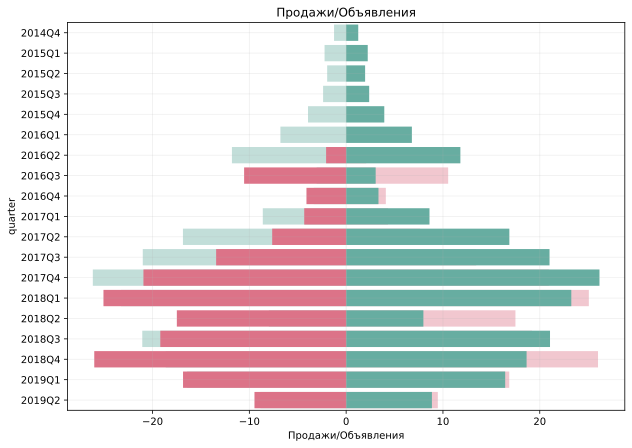

In [94]:


# Нормализуем данные, деля на 100
quarter_sales['total_exposed'] = quarter_sales['total_exposed'] / 100
quarter_sales['sale_day_exposed'] = quarter_sales['sale_day_exposed'] / - 100

# Создаем дополнительные столбцы для отображения в отрицательной области графика
quarter_sales['total_exposed_surplus'] = quarter_sales['total_exposed'] / - 1
quarter_sales['sale_day_exposed_surplus'] = quarter_sales['sale_day_exposed'] / - 1

# Определяем порядок кварталов для отображения на графике
quarters = ['2014Q4', '2015Q1', '2015Q2', '2015Q3', '2015Q4', '2016Q1', '2016Q2', '2016Q3', '2016Q4',
             '2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1', '2019Q2']

# Создание пирамидальной диаграммы
plt.figure(figsize=(10, 7))

# Рисуем полупрозрачные прямоугольники для фона
ax1 = sns.barplot(x='total_exposed_surplus', y='quarter', data=quarter_sales, order=quarters, color='#5bb9a9', alpha=0.4)
ax2 = sns.barplot(x='sale_day_exposed_surplus', y='quarter', data=quarter_sales, order=quarters, color='#ed627e', alpha=0.4)

# Рисуем основные прямоугольники
ax3 = sns.barplot(x='total_exposed', y='quarter', data=quarter_sales, order=quarters, color='#5bb9a9')
ax4 = sns.barplot(x='sale_day_exposed', y='quarter', data=quarter_sales, order=quarters, color='#ed627e')

# Добавляем заголовок и подпись оси X
plt.title("Продажи/Объявления")
plt.xlabel("Продажи/Объявления")

# Добавляем сетку
plt.grid(alpha=0.2)

# Отображаем график
plt.show()

### Объявления и продажи (2014-2019)

#### Этапы развития проекта

##### 1. Стартовый период (2014 Q4 - 2016 Q1)
- **Характеристика**: Низкая активность, отсутствие продаж
- **Причина**: Недостаточный трафик, этап становления проекта

#### 2. Переходный период (2016 Q2 - 2017 Q1)
- **Ключевое событие**: Первые продажи во 2 квартале 2016
- **Динамика**: Постепенный рост объявлений и продаж

#### 3. Период активного роста (с 2017 Q2)
- **Характеристика**: Существенное увеличение новых объявлений и продаж
- **Тенденция**: Стабильный рост обоих показателей

##### Ключевые показатели

| Показатель | Пиковое значение | Квартал |
|------------|------------------|---------|
| Объявления | 2648             | 2017 Q4 |
| Продажи    | 2646             | 2018 Q4 |



##### Развитие проекта:

Старт (2014Q4) -> Первые продажи (2016Q2) -> Активный рост (2017Q2) -> Стабилизация (2019Q2)


##### Анализ данных

1. **Отложенный эффект продаж**:
   - Пик объявлений: 2017 Q4 (2648)
   - Пик продаж: 2018 Q4 (2646)
   - Вывод: Продажи следуют за объявлениями с задержкой в несколько кварталов

2. **Соотношение объявлений и продаж**:
   - 2018 Q1: Продажи (2550) превысили новые объявления (2359)
   - Показывает высокую эффективность платформы

3. **Сезонность**:
   - Заметны колебания по кварталам
   - Требуется дополнительный анализ для выявления четких сезонных паттернов

##### Важные замечания

> **Примечание**: Снижение показателей в последних кварталах не следует интерпретировать как негативную тенденцию. Это может быть связано с исключением из данных объявлений, по которым продажи еще не состоялись.

##### Выводы

1. Проект демонстрирует устойчивый рост с момента запуска
2. Наблюдается положительная динамика как в количестве объявлений, так и в продажах
3. Платформа показывает высокую эффективность, особенно с 2017 года
4. Для полной оценки текущих трендов необходимы дополнительные данные о незавершенных сделках

---

**Рекомендация**: Продолжать мониторинг рынка для своевременного выявления новых тенденций и поддержания эффективности платформы.

### <a id='price_trends'></a> Ценовые тренды по сегментам (руб/м²)

In [95]:
# Создаем сводную таблицу с медианными ценами за квадратный метр по кварталам и ценовым классам
price_pivot = pd.pivot_table(data=df, index='quarter', columns='class_by_price', values='price_per_m2', aggfunc='median').reset_index()

# Добавляем столбец 'year', извлекая год из столбца 'quarter'
price_pivot['year'] = price_pivot['quarter'].dt.year

In [96]:


def process_price_pivot(price_pivot):
    # Расплавляем датафрейм один раз и используем для всех операций
    melted = price_pivot.melt(id_vars=['quarter', 'year'], var_name='Класс', value_name='Значение')
    
    # Группировка для мин/макс цен
    grouped = melted.groupby('Класс').agg(
        Мин_цена=('Значение', 'min'),
        Макс_цена=('Значение', 'max')
    ).reset_index()
    
    # Находим начальные и конечные значения
    start_quarter, end_quarter = price_pivot['quarter'].agg(['min', 'max'])
    df_start = melted[melted['quarter'] == start_quarter].set_index('Класс')[['Значение']]
    df_end = melted[melted['quarter'] == end_quarter].set_index('Класс')[['Значение']]
    
    # Объединяем начальные и конечные значения
    df_total = pd.concat([df_start, df_end], axis=1, keys=['Начало (2014 Q4)', 'Конец (2019 Q2)'])
    df_total.columns = df_total.columns.droplevel(1)  # Убираем второй уровень индекса
    df_total = df_total.reset_index()
    
    # Вычисляем изменение
    df_total['Изменение'] = round((df_total['Конец (2019 Q2)'] - df_total['Начало (2014 Q4)']) / df_total['Начало (2014 Q4)'] * 100, 2)
    
    # Объединяем все результаты
    result = grouped.merge(df_total, on='Класс')

    result.columns = result.columns.str.replace('_', ' ')
    
    return result

# Использование функции
total_result = process_price_pivot(price_pivot)
total_result

,Класс,Мин цена,Макс цена,Начало (2014 Q4),Конец (2019 Q2),Изменение
0,business,113627.272727,150720.838794,143465.553236,150720.838794,5.06
1,comfort,86813.186813,103769.265985,94701.754386,103550.295858,9.34
2,economy,82742.946708,97710.104780,85226.607199,96385.542169,13.09
3,elite,180783.582090,288293.118856,264642.384106,221799.746515,-16.19


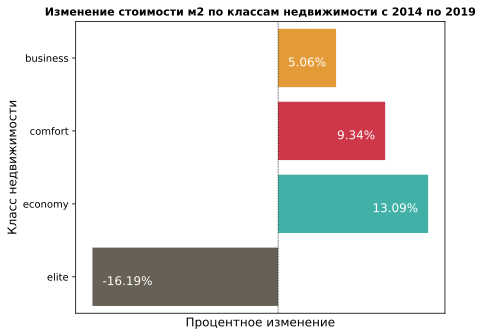

In [97]:
ax = sns.barplot(data=total_result, y='Класс', x='Изменение', palette=['#ff9f1c', '#e71d36', '#2ec4b6', '#696152'])

for p in ax.patches:
    percentage = p.get_width()
    percentage_label = '{:.2f}%'.format(percentage)
    y = p.get_y() + p.get_height() / 2
    x = p.get_width()
    
    # Определяем цвет текста и положение аннотации
    if percentage >= 0:
        text_color = 'white'
        x_offset = -10
    else:
        text_color = 'white'
        x_offset = 10
    
    ax.annotate(percentage_label, (x, y), 
                textcoords="offset points", 
                xytext=(x_offset, -5), 
                ha='left' if percentage < 0 else 'right', 
                va='center',
                fontsize=12, 
                color=text_color)

# Устанавливаем x=0 как центр графика
ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')

# Убираем x-метки, так как у нас есть аннотации
ax.set_xticks([])

# Добавляем заголовок
plt.title('Изменение стоимости м2 по классам недвижимости с 2014 по 2019', fontsize=11, fontweight='bold')

# Настраиваем подписи осей
ax.set_xlabel('Процентное изменение', fontsize=12)
ax.set_ylabel('Класс недвижимости', fontsize=12)

plt.tight_layout()
plt.show()

### <a id='volatility'></a> Волатильность цен (Коэффициент вариации)

In [98]:
# Вычисляем стандартное отклонение и среднее значение цены за квадратный метр для каждого ценового класса
dev_means = df.groupby('class_by_price').agg(deviation=('price_per_m2', 'std'),
 means=('price_per_m2', 'mean'))

In [99]:
# Вычисляем коэффициент вариации для каждого класса недвижимости
for class_type in ['economy', 'comfort', 'business', 'elite']:
    cv = dev_means.loc[class_type, 'deviation'] / dev_means.loc[class_type, 'means'] * 100
    dev_means.loc[class_type, 'Коэффициент вариации'] = f"{cv:.2f}%"

# Создаем новый DataFrame с коэффициентами вариации и переименовываем столбцы
var_coef = dev_means['Коэффициент вариации'].reset_index().rename(columns={'class_by_price': 'Класс'})

# Переводим названия классов на русский язык
var_coef['Класс'] = var_coef['Класс'].map({
    'business': 'Бизнес',
    'comfort': 'Комфорт',
    'economy': 'Эконом',
    'elite': 'Элитный'
})

# Сортируем DataFrame по значению коэффициента вариации
mask = var_coef['Коэффициент вариации'].str.rstrip('%').astype(float).sort_values().index.tolist()
var_coef = var_coef.iloc[mask].reset_index(drop=True)

# Выводим результат
var_coef

,Класс,Коэффициент вариации
0,Эконом,28.74%
1,Бизнес,31.01%
2,Комфорт,32.26%
3,Элитный,64.34%


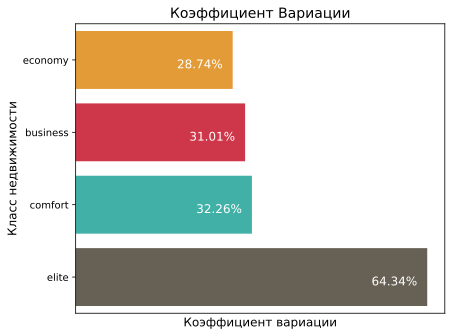

In [100]:
# Преобразуем 'Коэффициент вариации' в числовой формат
dev_means['Коэффициент вариации'] = dev_means['Коэффициент вариации'].str[:-1].astype(float)

# Определяем порядок сортировки по коэффициенту вариации
order = dev_means['Коэффициент вариации'].sort_values().index.tolist()

# Создаем столбчатую диаграмму
ax = sns.barplot(data=dev_means, y=dev_means.index, x='Коэффициент вариации', palette=['#ff9f1c',
                                                                                        '#e71d36', '#2ec4b6', '#696152'], order=order)

# Добавляем подписи значений на столбцы
for p in ax.patches:
    percentage = p.get_width()
    percentage_label = '{:.2f}%'.format(percentage)
    y = p.get_y() + p.get_height() / 2
    x = p.get_width()
    
    # Определяем цвет текста и положение аннотации
    if percentage >= 0:
        text_color = 'white'
        x_offset = -10
    else:
        text_color = 'white'
        x_offset = 10
    
    ax.annotate(percentage_label, (x, y),
                textcoords="offset points",
                xytext=(x_offset, -5),
                ha='left' if percentage < 0 else 'right',
                va='center',
                fontsize=12,
                color=text_color)

# Убираем x-метки, так как у нас есть аннотации
ax.set_xticks([])

# Добавляем заголовок
plt.title('Коэффициент Вариации', fontsize=14)

# Настраиваем подписи осей
ax.set_xlabel('Коэффициент вариации', fontsize=12)
ax.set_ylabel('Класс недвижимости', fontsize=12)

# Оптимизируем расположение элементов графика
plt.tight_layout()

# Отображаем график
plt.show()

### <a id='prices_dynamics'></a> Динамика цен по годам

In [101]:

# Вычисляем средние цены по годам для каждого класса недвижимости
year_avg = price_pivot.groupby('year').mean()

# Создаем новый DataFrame с выбранными столбцами и сбрасываем индекс
year_price = year_avg.reset_index()[['year', 'economy', 'comfort', 'business', 'elite']]

# Переименовываем столбцы на русский язык
year_price.columns = ['Год', 'Эконом', 'Комфорт', 'Бизнес', 'Элитный']

# Выводим результат
year_price


,Год,Эконом,Комфорт,Бизнес,Элитный
0,2014,85226.607199,94701.754386,143465.553236,264642.384106
1,2015,86504.001794,93521.983390,129522.700572,207583.951984
2,2016,85723.910293,92628.764038,133157.060090,241555.590541
3,2017,86718.462739,96091.126450,131475.060827,205550.281588
4,2018,91497.031833,98580.071301,131648.272473,210022.071866
5,2019,97047.823474,103659.780922,143354.873418,218827.801185


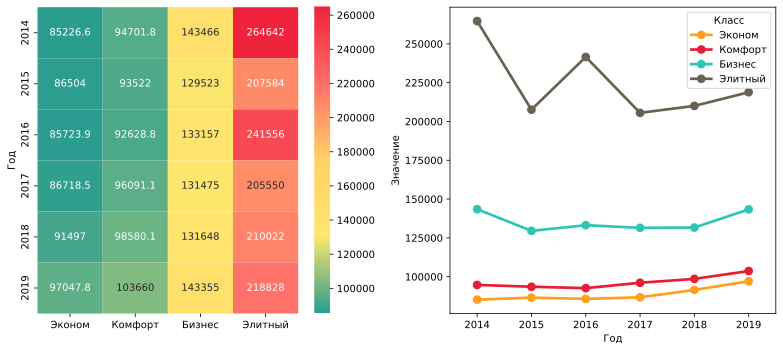

In [102]:
# Преобразуем данные из широкого формата в длинный
melted_year_price = year_price.melt(id_vars=['Год'], var_name='Класс', value_name='Значение')

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax1, ax2 = axes

# Создаем тепловую карту
sns.heatmap(year_price.set_index('Год'), cmap=cmap, annot=True, fmt='g', ax=ax1)

# Создаем график с точками и линиями
sns.pointplot(melted_year_price, y='Значение', x='Год', hue='Класс', ax=ax2, palette=['#ff9f1c',
                                                                                       '#e71d36', '#2ec4b6', '#696152'])

# Оптимизируем расположение графиков
plt.tight_layout()

# Отображаем графики
plt.show()

### <a id='seg_break'></a> Разрыв между сегментами

In [103]:

# Группировка данных по годам и вычисление средней цены для каждого сегмента
yearly_avg = price_pivot.groupby('year').agg({
    'economy': 'mean',
    'comfort': 'mean',
    'business': 'mean',
    'elite': 'mean'
}).reset_index()

# Расчет процентной разницы между сегментами
yearly_avg['Элитный/Бизнес'] = (yearly_avg['elite'] - yearly_avg['business']) / yearly_avg['business'] * 100
yearly_avg['Бизнес/Комфорт'] = (yearly_avg['business'] - yearly_avg['comfort']) / yearly_avg['comfort'] * 100
yearly_avg['Комфорт/Эконом'] = (yearly_avg['comfort'] - yearly_avg['economy']) / yearly_avg['economy'] * 100

# Округление результатов до одного десятичного знака
class_range = yearly_avg[['year', 'Элитный/Бизнес', 'Бизнес/Комфорт', 'Комфорт/Эконом']].round(1)

class_range

class_by_price,year,Элитный/Бизнес,Бизнес/Комфорт,Комфорт/Эконом
0,2014,84.5,51.5,11.1
1,2015,60.3,38.5,8.1
2,2016,81.4,43.8,8.1
3,2017,56.3,36.8,10.8
4,2018,59.5,33.5,7.7
5,2019,52.6,38.3,6.8


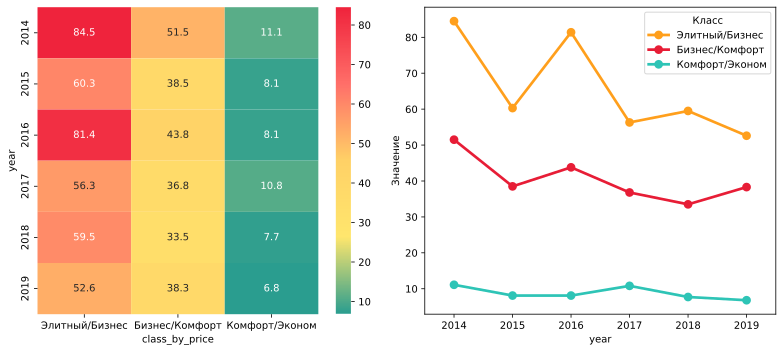

In [104]:
# Преобразуем данные из широкого формата в длинный
melted_class_range = class_range.melt(id_vars=['year'], var_name='Класс', value_name='Значение')

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax1, ax2 = axes

# Создаем тепловую карту
sns.heatmap(class_range.set_index('year'), cmap=cmap, annot=True, fmt='g', ax=ax1)

# Создаем график с точками и линиями
sns.pointplot(melted_class_range, y='Значение', x='year', hue='Класс', ax=ax2, palette=['#ff9f1c',
                                                                                         '#e71d36', '#2ec4b6', '#696152'])

# Поворачиваем метки оси X для тепловой карты
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, ha='center')

# Оптимизируем расположение графиков
plt.tight_layout()

# Отображаем графики
plt.show()

### <a id='seasonality'></a> Сезонность

In [105]:
# Создание копии DataFrame price_pivot для расчета квартальных отклонений цен
qurter_deviations = price_pivot.copy()

# Расчет процентного отклонения цен каждого квартала от среднегодового значения
# для всех классов жилья (элитный, бизнес, комфорт, эконом)
for i in ['elite', 'business', 'comfort', 'economy']:
    qurter_deviations[f'{i}_dev'] = qurter_deviations.apply(
        lambda row: (row[i] / year_avg.loc[row['year'], i] - 1) * 100, axis=1
    )

# Вычисление средних отклонений по кварталам для определения сезонности
# Группировка по номеру квартала (последние 2 символа в столбце 'quarter')
seasonality = qurter_deviations.groupby(qurter_deviations['quarter'].astype(str).str[-2:]).mean()[['elite_dev', 'business_dev',
                                                                                                    'comfort_dev', 'economy_dev']].reset_index()

# Переименование столбцов для удобства чтения и анализа
seasonality.columns = ['Квартал', 'Элитный', 'Бизнес', 'Комфорт', 'Эконом']

# Вывод результирующей таблицы сезонности
seasonality

,Квартал,Элитный,Бизнес,Комфорт,Эконом
0,Q1,0.294707,1.804088,-1.240859,-1.373200
1,Q2,6.752391,-0.423584,1.514942,-0.010226
2,Q3,-0.978710,-0.707808,-0.834347,1.630031
3,Q4,-6.264130,-0.814258,0.393394,0.079401


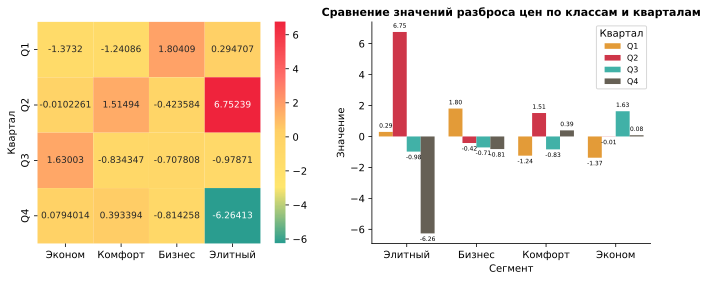

In [106]:
# Преобразование данных для визуализации
seasonality_df_melted = seasonality.reset_index(drop=True).melt('Квартал', var_name='Сегмент', value_name='Значение')

# Изменение порядка столбцов в таблице сезонности
new_order = ['Квартал', 'Эконом', 'Комфорт', 'Бизнес', 'Элитный']
seasonality = seasonality[new_order]

# Создание фигуры с двумя графиками
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax1, ax2 = axes

# Создание столбчатой диаграммы
sns.barplot(x='Сегмент', y='Значение', hue='Квартал', data=seasonality_df_melted, 
            palette=['#ff9f1c', '#e71d36', '#2ec4b6', '#696152'], ax=ax2)

# Создание тепловой карты
sns.heatmap(seasonality.set_index('Квартал'), cmap=cmap, annot=True, fmt='g', ax=ax1, annot_kws={'size': 9}) 

# Настройка легенды для столбчатой диаграммы
ax2.legend(title='Квартал', title_fontsize='10', fontsize='8')

# Добавление подписей значений на столбцы
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3, fontsize=6)
    
# Настройка заголовка и подписи оси Y для столбчатой диаграммы
ax2.set_title('Сравнение значений разброса цен по классам и кварталам', fontsize=11, fontweight='bold')
plt.ylabel('Значение')

# Удаление верхней и правой границ графика
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Отображение графиков
plt.show()

#### Переведем данные в индекс от -1 до 1 для удобства

In [107]:
# Преобразование данных из широкого формата в длинный
seasonality_melted = seasonality.melt(id_vars='Квартал', value_name='Разброс цен', var_name='Класс')

# Расчет индекса сезонности с использованием метода min-max нормализации
# и последующего преобразования в диапазон от -1 до 1
seasonality_melted['Индекс сезонности'] = seasonality_melted.apply(lambda x: 2 * (x['Разброс цен'] - seasonality_melted['Разброс цен'].min()) /
 (seasonality_melted['Разброс цен'].max() - seasonality_melted['Разброс цен'].min()) - 1, axis=1)

# Преобразование данных обратно в широкий формат с индексом сезонности в качестве значений
seasonality_index = seasonality_melted.pivot(columns='Класс', index='Квартал', values='Индекс сезонности').reset_index()

# Изменение порядка столбцов для удобства анализа
new_order = ['Квартал', 'Эконом', 'Комфорт', 'Бизнес', 'Элитный']
seasonality_index = seasonality_index[new_order]

# Вывод результирующей таблицы с индексами сезонности
seasonality_index

Класс,Квартал,Эконом,Комфорт,Бизнес,Элитный
0,Q1,-0.248504,-0.228170,0.239689,0.007771
1,Q2,-0.039082,0.195261,-0.102595,1.000000
2,Q3,0.212945,-0.165709,-0.146266,-0.187891
3,Q4,-0.025311,0.022934,-0.162622,-1.000000


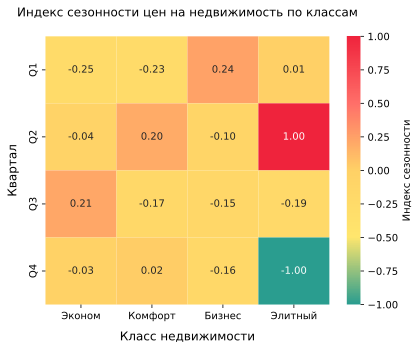

In [108]:
# Создание фигуры с заданным размером
plt.figure(figsize=(6, 5))

# Создание тепловой карты для визуализации индексов сезонности
heatmap = sns.heatmap(seasonality_index.set_index('Квартал'), 
                      cmap=cmap, 
                      annot=True, 
                      fmt='.2f', 
                      annot_kws={'size': 10},
                      center=0,
                      cbar_kws={'label': 'Индекс сезонности'})

# Настройка заголовка и подписей осей
plt.title('Индекс сезонности цен на недвижимость по классам', fontsize=12, pad=20)
plt.xlabel('Класс недвижимости', fontsize=12, labelpad=10)
plt.ylabel('Квартал', fontsize=12, labelpad=10)

# Поворот меток на оси X для лучшей читаемости
plt.xticks(rotation=0)

# Настройка размера шрифта для меток осей
plt.tick_params(axis='both', which='major', labelsize=10)

# Настройка расположения графика
plt.tight_layout()

# Отображение графика
plt.show()

#### Пиковые и низкие сезоны

In [109]:
# Инициализация пустого списка для хранения результатов
result = []

# Итерация по классам недвижимости
for col in ['Элитный', 'Бизнес', 'Комфорт', 'Эконом']:
   # Нахождение максимального и минимального значения для каждого класса
   max_value = seasonality[col].max()
   min_value = seasonality[col].min()
   
   # Определение пикового сезона (квартал с максимальным значением)
   peak_season = f"{seasonality.loc[seasonality[col].idxmax(), 'Квартал']} ({max_value:.2f}%)"
   
   # Определение низкого сезона (квартал с минимальным значением)
   low_season = f"{seasonality.loc[seasonality[col].idxmin(), 'Квартал']} ({min_value:.2f}%)"
   
   # Расчет разброса цен (разница между максимальным и минимальным значением)
   range_ = f"{max_value - min_value:.2f}%"
   
   # Добавление результатов в список
   result.append([col, peak_season, low_season, range_])

# Создание DataFrame из полученных результатов
result = pd.DataFrame(result, columns=['Класс', 'Пиковый сезон', 'Низкий сезон', 'Разброс цен'])

# Вывод результата без индекса и с выравниванием колонок
print(result.to_string(index=False))


  Класс Пиковый сезон Низкий сезон Разброс цен
Элитный    Q2 (6.75%)  Q4 (-6.26%)      13.02%
 Бизнес    Q1 (1.80%)  Q4 (-0.81%)       2.62%
Комфорт    Q2 (1.51%)  Q1 (-1.24%)       2.76%
 Эконом    Q3 (1.63%)  Q1 (-1.37%)       3.00%


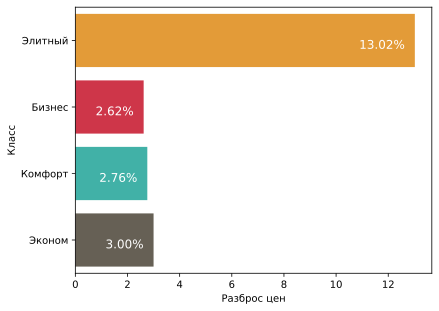

In [110]:
# Преобразование столбца 'Разброс цен' из строкового формата в числовой
result['Разброс цен'] = result['Разброс цен'].str.rstrip('%').astype(float)

# Создание горизонтальной столбчатой диаграммы
ax = sns.barplot(data=result, y='Класс', x='Разброс цен', palette=['#ff9f1c', '#e71d36', '#2ec4b6', '#696152'])

# Добавление подписей значений на столбцы
for p in ax.patches:
    percentage = p.get_width()
    percentage_label = '{:.2f}%'.format(percentage)
    y = p.get_y() + p.get_height() / 2
    x = p.get_width()
    
    # Определение цвета текста и положения аннотации
    if percentage >= 0:
        text_color = 'white'
        x_offset = -10
    else:
        text_color = 'white'
        x_offset = 10
    
    # Добавление аннотации (подписи значения) к каждому столбцу
    ax.annotate(percentage_label, (x, y), 
                textcoords="offset points", 
                xytext=(x_offset, -5), 
                ha='left' if percentage < 0 else 'right', 
                va='center',
                fontsize=12, 
                color=text_color)

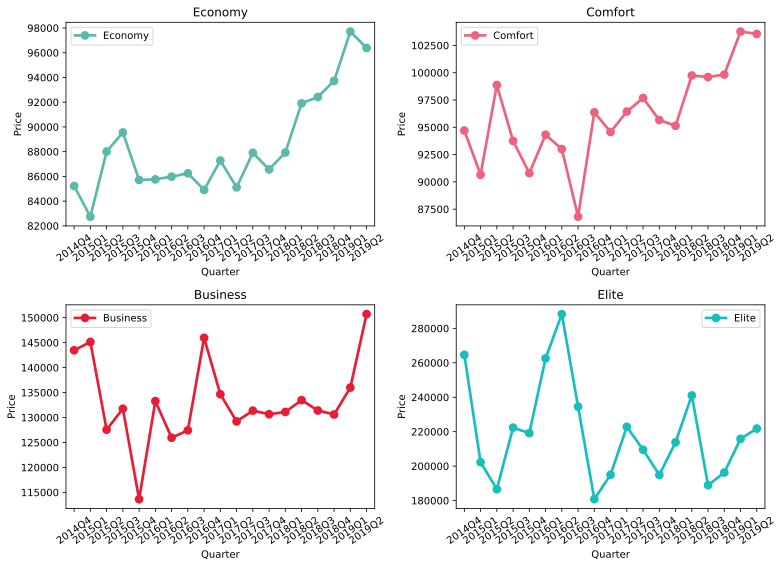

In [111]:
# Создаем фигуру с 2x2 подграфиками
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Создаем точечные графики для каждого класса недвижимости
sns.pointplot(data=price_pivot, x='quarter', y='economy', ax=axes[0, 0], label='Economy', color='#5bb9a9')
sns.pointplot(data=price_pivot, x='quarter', y='comfort', ax=axes[0, 1], label='Comfort', color='#ed627e')
sns.pointplot(data=price_pivot, x='quarter', y='business', ax=axes[1, 0], label='Business', color='#e71d36')
sns.pointplot(data=price_pivot, x='quarter', y='elite', ax=axes[1, 1], label='Elite', color='#17bebb')

# Устанавливаем заголовки для каждого подграфика
axes[0, 0].set_title('Economy')
axes[0, 1].set_title('Comfort')
axes[1, 0].set_title('Business')
axes[1, 1].set_title('Elite')

# Поворачиваем метки оси X для лучшей читаемости и устанавливаем подписи осей
for ax in axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='center')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Price')

# Настраиваем расположение графиков
plt.tight_layout()

# Добавляем легенду
plt.legend()

# Отображаем график
plt.show()

#### Анализ динамики цен на недвижимость (2014-2019)

#### 1. Ценовые тренды по сегментам (руб/м²)

| Сегмент | Мин. цена | Макс. цена | Начало (2014 Q4) | Конец (2019 Q2) | Изменение |
|---------|-----------|------------|-------------------|------------------|------------|
| Элитный | 180,784   | 288,293    | 264,642           | 221,800          | -16.2%     |
| Бизнес  | 113,627   | 150,721    | 143,466           | 150,721          | +5.1%      |
| Комфорт | 86,988    | 103,970    | 94,702            | 103,659          | +9.5%      |
| Эконом  | 82,743    | 98,111     | 85,227            | 96,681           | +13.4%     |

#### 2. Динамика цен по годам

| Год | Элитный    | Бизнес     | Комфорт    | Эконом     |
|-----|------------|------------|------------|------------|
| 2014| 264,642    | 143,466    | 94,702     | 85,227     |
| 2015| 208,370*   | 129,742*   | 93,832*    | 86,497*    |
| 2016| 241,556*   | 133,280*   | 92,748*    | 86,009*    |
| 2017| 205,550*   | 131,475*   | 96,197*    | 86,949*    |
| 2018| 210,022*   | 131,648*   | 98,733*    | 91,793*    |
| 2019| 218,828*   | 143,355*   | 103,814*   | 97,396*    |

*Среднее значение за год

#### 3. Волатильность цен (Коэффициент вариации)

| Сегмент | Волатильность |
|---------|---------------|
| Элитный | 64.29%        |
| Бизнес  | 31.04%        |
| Комфорт | 32.40%        |
| Эконом  | 28.78%        |

#### 4. Сезонность цен (среднее отклонение от годового тренда)

| Класс   | Пиковый сезон | Низкий сезон  | Разброс цен |
|---------|---------------|---------------|-------------|
| Элитный | Q2 (6.68%)    | Q4 (-6.04%)   | 12.73%      |
| Бизнес  | Q1 (1.75%)    | Q4 (-0.86%)   | 2.61%       |
| Комфорт | Q2 (1.53%)    | Q1 (-1.13%)   | 2.66%       |
| Эконом  | Q3 (1.55%)    | Q1 (-1.37%)   | 2.92%       |


#### 5. Разрыв между сегментами (% от нижнего сегмента)

| Год | Элитный/Бизнес | Бизнес/Комфорт | Комфорт/Эконом |
|-----|----------------|-----------------|-----------------|
| 2014| 84.5%          | 51.5%           | 11.1%           |
| 2015| 60.6%          | 38.3%           | 8.5%            |
| 2016| 81.2%          | 43.7%           | 7.8%            |
| 2017| 56.3%          | 36.7%           | 10.6%           |
| 2018| 59.5%          | 33.3%           | 7.6%            |
| 2019| 52.6%          | 38.1%           | 6.6%            |

#### 6. Ключевые наблюдения

1. Наибольший рост цен в эконом-сегменте: +13.4%
2. Высокая волатильность в элитном сегменте
3. Сезонность наиболее выражена в элитном и комфорт-сегментах
4. Сокращение разрыва между комфорт и эконом-классом
5. Стабильный рост цен в доступных сегментах с 2018 года

### <a id='quarter_sales'></a> Поквартальные продажи по топ-10 городов

In [112]:
# Вычисляем разницу с помощью pd.Timedelta
df['sale_day'] = df.apply(lambda x: (x['first_day_exposition'] + pd.Timedelta(days=x['days_exposition'])).strftime("%Y-%m-%d") if x['days_exposition'] != 0 else 0, axis=1)
df['sale_day'] = df['sale_day'].apply(lambda row: pd.to_datetime(row) if row != 0 else np.nan)

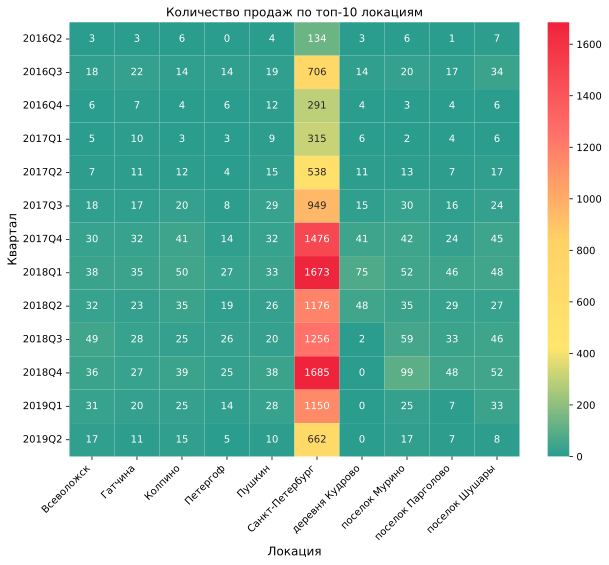

In [113]:
# Выбираем 20 самых популярных локаций
locality_df = df[df.locality_name.isin(df.locality_name.value_counts().index[:20])]

# Группируем данные по дате продажи и локации
df_grouped = locality_df.groupby(['sale_day', 'locality_name']).size()
df_grouped = df_grouped.reset_index()

# Добавляем столбец с кварталами
df_grouped['quarter'] = df_grouped['sale_day'].dt.to_period('Q')

# Группируем данные по кварталам и локациям, суммируя количество продаж
df_quarterly = df_grouped.groupby(['quarter', 'locality_name'])[0].sum().reset_index()

# Выбираем топ-10 локаций по общему количеству продаж
top_10_localities = df_quarterly.groupby('locality_name')[0].sum().nlargest(10).index
df_top_10 = df_quarterly[df_quarterly['locality_name'].isin(top_10_localities)]

# Создаем сводную таблицу
pivot_data = df_top_10.pivot(index='quarter', columns='locality_name', values=0)
pivot_data = pivot_data.sort_index()

# Заполняем NaN значения нулями
pivot_data = pivot_data.fillna(0)

# Создаем тепловую карту
plt.figure(figsize=(9, 8))
sns.heatmap(pivot_data, cmap=cmap, annot=True, fmt='g')
plt.title('Количество продаж по топ-10 локациям', fontsize=12)
plt.xlabel('Локация', fontsize=12)
plt.ylabel('Квартал', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### <a id='m2'></a> Цена за м2 по Топ-12 городам

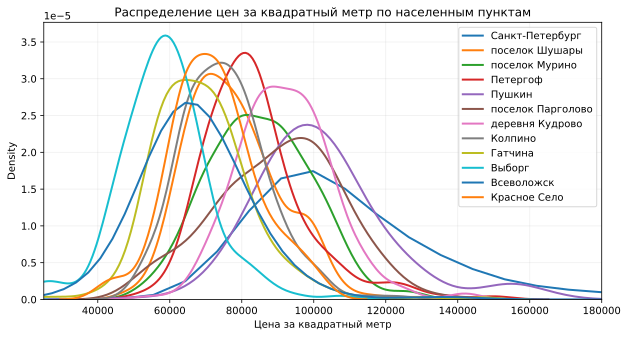

In [114]:
# Выбираем данные для 10 самых популярных локаций
l_df = df[df.locality_name.isin(df.locality_name.value_counts().index[:12])]

# Создаем фигуру и оси для графика
fig, ax = plt.subplots(figsize=(10, 5))

# Для каждой локации строим график плотности распределения цен за квадратный метр
for locality in l_df.locality_name.unique():
    sns.kdeplot(l_df[l_df.locality_name == locality].price_per_m2, label=locality, linewidth=2)

plt.grid(True, alpha=0.2) # сетка
plt.legend(bbox_to_anchor = (1,1)) # положение легенды
plt.title('Распределение цен за квадратный метр по населенным пунктам', loc = 'center') # название графика
plt.xlabel('Цена за квадратный метр') # подпись оси x
plt.xlim(25000, 180000) # ограничение значений оси X
plt.show()

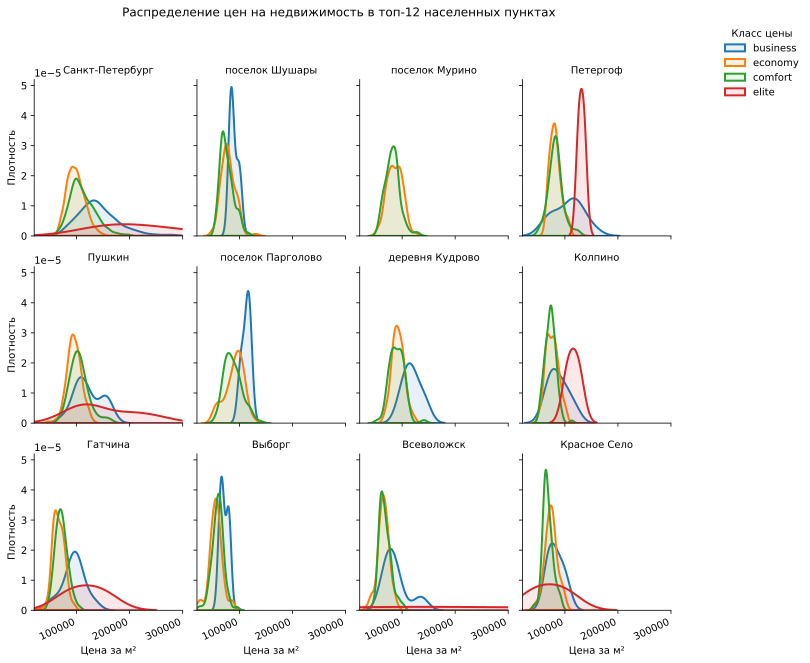

In [115]:
# Выбираем топ-12 населенных пунктов по количеству объявлений
top_12 = df.groupby('locality_name').size().nlargest(12).index.tolist()

# Создаем сетку графиков FacetGrid
g = sns.FacetGrid(data=df[df['locality_name'].isin(top_12)], # Используем только данные для топ-12 населенных пунктов
                  col='locality_name',  # Разбиваем по названиям населенных пунктов
                  hue='class_by_price', # Цвет линий зависит от класса цены
                  col_wrap=4,           # Располагаем графики в 4 колонки
                  height=3,             # Высота каждого графика
                  aspect=0.7)           # Соотношение ширины к высоте

# Наносим график плотности на каждый подграфик
g.map_dataframe(sns.kdeplot, 
                x='price_per_m2',  # Данные по оси X
                fill=True,         # Заполнять область под кривой
                alpha=0.1,         # Прозрачность заливки
                linewidth=2)       # Толщина линии

# Устанавливаем пределы оси X
g.set(xlim=(20000, 300000))

# Устанавливаем подписи осей
g.set_axis_labels('Цена за м²', 'Плотность')

# Устанавливаем заголовки для каждого подграфика
g.set_titles('{col_name}')

# Добавляем общий заголовок для всего графика
g.fig.suptitle('Распределение цен на недвижимость в топ-12 населенных пунктах', fontsize=12, y=1.02)

# Поворачиваем подписи оси X для лучшей читаемости
g.fig.autofmt_xdate(rotation=25, ha='right')

# Добавляем легенду
g.add_legend(title='Класс цены', bbox_to_anchor=(1.05, 1), loc='upper left')

# Оптимизируем расположение графиков
plt.tight_layout()

# Отображаем график
plt.show()

### <a id='city_classes'></a> Доля классов жилья в населенных пунктах

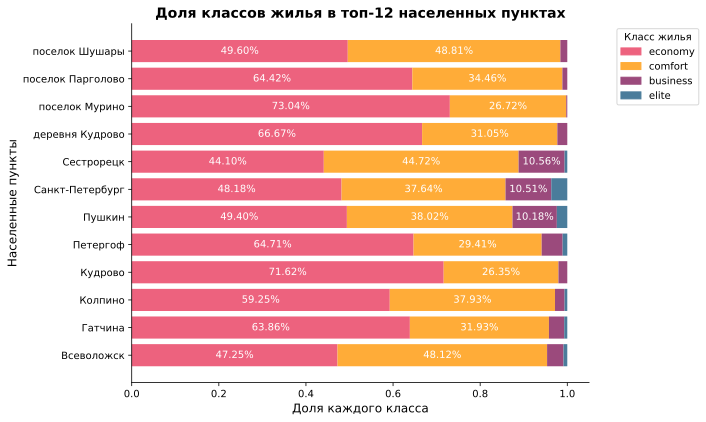

In [116]:
# Выбираем топ-12 локаций по сумме последних цен
top_12 = df.groupby('locality_name')['last_price'].sum().nlargest(12).index.tolist()

# Считаем общее количество объявлений для каждой из топ-12 локаций
total = df[df['locality_name'].isin(top_12)].groupby('locality_name').size().reset_index(name='total_count')

# Считаем количество объявлений для каждого класса недвижимости в каждой из топ-12 локаций
locs = df[df['locality_name'].isin(top_12)].groupby(['locality_name', 'class_by_price']).size().reset_index(name='class_count')

# Объединяем locs и locs_a
portion = locs.merge(total, on='locality_name')

# Вычисляем долю
portion['percentage'] = portion['class_count'] / portion['total_count']

# Создаем словарь для сортировки классов
class_order = {
    'economy': 0,
    'comfort': 1,
    'business': 2,
    'elite': 3
}

# Добавляем новый столбец для сортировки
portion['class_order'] = portion['class_by_price'].map(class_order)

# Сортируем данные
portion_sorted = portion.sort_values(['locality_name', 'class_order'], ascending=[True, True])

# Удаляем вспомогательный столбец
portion_sorted = portion_sorted.drop('class_order', axis=1)

# Увеличиваем размер фигуры
plt.figure(figsize=(10, 6))

# Создаем график
ax = plt.gca()
colors = {
    'economy': '#ed627e',
    'comfort': '#ffac38',
    'business': '#9b4a7c',
    'elite': '#4a7c9b'
}

localities = portion_sorted['locality_name'].unique()
locality_positions = range(len(localities))

for i, locality in enumerate(localities):
    locality_data = portion_sorted[portion_sorted['locality_name'] == locality]
    left = 0
    for _, row in locality_data.iterrows():
        ax.barh(i, row['percentage'], left=left, color=colors.get(row['class_by_price'], '#999999'))
        if row['percentage'] > 0.05:  # Показываем метку только если доля больше 5%
            ax.text(left + row['percentage']/2, i, f"{row['percentage']:.2%}",
                    ha='center', va='center', color='white', fontsize=10
                    )
        left += row['percentage']

# Настройка заголовка и меток осей
plt.title('Доля классов жилья в топ-12 населенных пунктах', fontsize=14, fontweight='bold')
plt.xlabel('Доля каждого класса', fontsize=12)
plt.ylabel('Населенные пункты', fontsize=12)

# Создаем легенду
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in colors]
plt.legend(handles, colors.keys(), title='Класс жилья', bbox_to_anchor=(1.05, 1), loc='upper left')

# Настраиваем метки оси Y
ax.set_yticks(locality_positions)
ax.set_yticklabels(localities, fontsize=10)

# Удаление рамки вокруг графика
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Настраиваем макет, чтобы легенда не перекрывала график
plt.tight_layout()
plt.show()

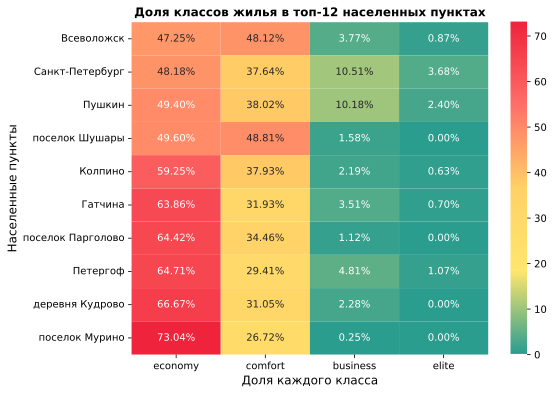

In [117]:
# Выбираем топ-12 локаций по количеству объявлений
top_12 = df.groupby('locality_name').size().nlargest(12).index.tolist()

# Фильтруем данные по топ-12 локациям и выбираем нужные столбцы
data = portion.loc[portion['locality_name'].isin(top_12)][['locality_name', 'class_by_price', 'percentage']]

# Переводим процентные доли в проценты (умножаем на 100)
data['percentage'] = data['percentage'] * 100

# Создаем сводную таблицу
portion_pivot = pd.pivot_table(data=data,
                               index='locality_name',
                               columns='class_by_price',
                               values='percentage',
                               fill_value=0)[['economy', 'comfort', 'business', 'elite']].sort_values(by='economy')

# Создание строковых представлений с процентами
annot = portion_pivot.applymap(lambda x: f'{x:.2f}%')

plt.figure(figsize=(8, 6))

# Создание тепловой карты
sns.heatmap(portion_pivot, annot=annot, fmt='', cmap=cmap)

# Настройка заголовка и меток осей
plt.title('Доля классов жилья в топ-12 населенных пунктах', fontsize=12, fontweight='bold')
plt.xlabel('Доля каждого класса', fontsize=12)
plt.ylabel('Населенные пункты', fontsize=12)

plt.show()

#### Средняя доля классов по топ-12

In [118]:
cities = df.groupby('locality_name').size().nlargest(12).index.tolist()
cities_df = df[df['locality_name'].isin(cities)]
cities_class_percent = (cities_df.groupby(['locality_name', 'class_by_price']).size() / cities_df.groupby('locality_name').size() * 100).reset_index(name='percent')
cities_class_percent = cities_class_percent.groupby('class_by_price')['percent'].mean()
cities_percent = cities_class_percent.reset_index(name='Средняя доля по топ-12')
cities_percent = cities_percent.rename(columns={'class_by_price': 'Класс'}).sort_values(by='Средняя доля по топ-12')
cities_percent['Класс'] = cities_percent['Класс'].map({'economy':'Эконом', 'comfort': 'Комфорт', 'business': 'Бизнес', 'elite': 'Элитный'})
cities_percent

,Класс,Средняя доля по топ-12
3,Элитный,1.389093
0,Бизнес,4.004193
1,Комфорт,36.420635
2,Эконом,58.649111


#### Средняя доля классов

In [119]:
total_classes = (df.groupby('class_by_price').size() / len(df) * 100).reset_index(name='Доля объявлений').rename(columns={'class_by_price': 'Класс'}).sort_values(by='Доля объявлений')
total_classes['Класс'] = total_classes['Класс'].map({'economy':'Эконом', 'comfort': 'Комфорт', 'business': 'Бизнес', 'elite': 'Элитный'}).sort_values()
total_classes

,Класс,Доля объявлений
3,Элитный,2.640794
0,Бизнес,7.990468
1,Комфорт,37.330999
2,Эконом,52.037740




#### 1. Распределение классов жилья:

| Класс   | Средняя доля |
|---------|--------------|
| Эконом | 52.04%       |
| Комфорт | 37.33%       |
| Бизнес| 8.00%        |
| Элитный   | 2.64%        |

#### 2. Топ-3 населенных пункта по доле элитного жилья:

| Населенный пункт | Доля elite |
|------------------|------------|
| Санкт-Петербург  | 3.64%      |
| Пушкин           | 2.38%      |
| Петергоф         | 1.06%      |

#### 3. Населенные пункты с наибольшим дисбалансом классов:

| Населенный пункт | Доля economy | Доля comfort | Разница |
|------------------|--------------|--------------|---------|
| поселок Мурино   | 73.65%       | 26.12%       | 47.53%  |
| деревня Кудрово  | 67.41%       | 30.36%       | 37.05%  |
| Петергоф         | 64.89%       | 29.26%       | 35.63%  |

#### Выводы:

1. Рынок жилья в регионе сильно смещен в сторону экономкласса, который составляет более половины всего предложения.

2. Элитное жилье представлено минимально, в основном сконцентрировано в Санкт-Петербурге и исторических пригородах.

3. Наблюдается существенный разрыв между долями экономкласса и комфорткласса, особенно в активно застраиваемых пригородах (Мурино, Кудрово).

4. Санкт-Петербург демонстрирует наиболее сбалансированное распределение классов жилья, что отражает его статус мегаполиса.

5. В некоторых населенных пунктах (Парголово, Кудрово, Мурино) полностью отсутствует элитное жилье, что может указывать на их ориентацию на массовый сегмент покупателей.

6. Всеволожск и Сестрорецк показывают наиболее равномерное распределение между экономклассом и комфорт-классом, что может свидетельствовать о их привлекательности для среднего класса.



## <a id='section_4'></a> 4️⃣ Факторы, влияющие на стоимость недвижимости


[**Главное меню**](#menu)

In [120]:
# Выбираем числовые столбцы и рассчитываем корреляцию с 'last_price' и 'price_per_m2'
corr_df = df.select_dtypes(np.number).corr()[['last_price', 'price_per_m2']].reset_index()

# Преобразуем DataFrame из широкого формата в длинный для удобства фильтрации
corr_df_melted = corr_df.melt(id_vars=['index'], var_name='prices', value_name='corr')

# Фильтруем коэффициенты корреляции: оставляем только те, которые больше 0.2 или меньше -0.2,
# и исключаем строки с индексами 'last_price', 'price_per_m2', 'price_per_m2_usd', 'last_price_usd'
corr_df_melted_filtered = corr_df_melted.loc[(corr_df_melted['corr'] > 0.2) | (corr_df_melted['corr'] < -0.2)].loc[
    ~corr_df_melted['index'].isin(['last_price', 'price_per_m2', 'price_per_m2_usd', 'last_price_usd'])]

# Преобразуем DataFrame обратно в широкий формат
corr_df_melted_filtered = corr_df_melted_filtered.pivot(index='index', columns='prices', values='corr').reset_index()

# Извлекаем строки с ненулевыми значениями корреляции для 'last_price' и сортируем по значению корреляции
last_price_corr = corr_df_melted_filtered[~corr_df_melted_filtered['last_price'].isna()][['index', 'last_price']].sort_values(by='last_price')

# Извлекаем строки с ненулевыми значениями корреляции для 'price_per_m2' и сортируем по значению корреляции
price_per_m2_corr = corr_df_melted_filtered[~corr_df_melted_filtered['price_per_m2'].isna()][['index', 'price_per_m2']].sort_values(by='price_per_m2')

# Получаем уникальные названия признаков с сильной корреляцией для 'last_price'
last_price_features = last_price_corr['index'].unique().tolist()

# Получаем уникальные названия признаков с сильной корреляцией для 'price_per_m2'
price_per_m2_corr_features = price_per_m2_corr['index'].unique().tolist()


#### <a id='last_price'></a> Стоимость недвижимости

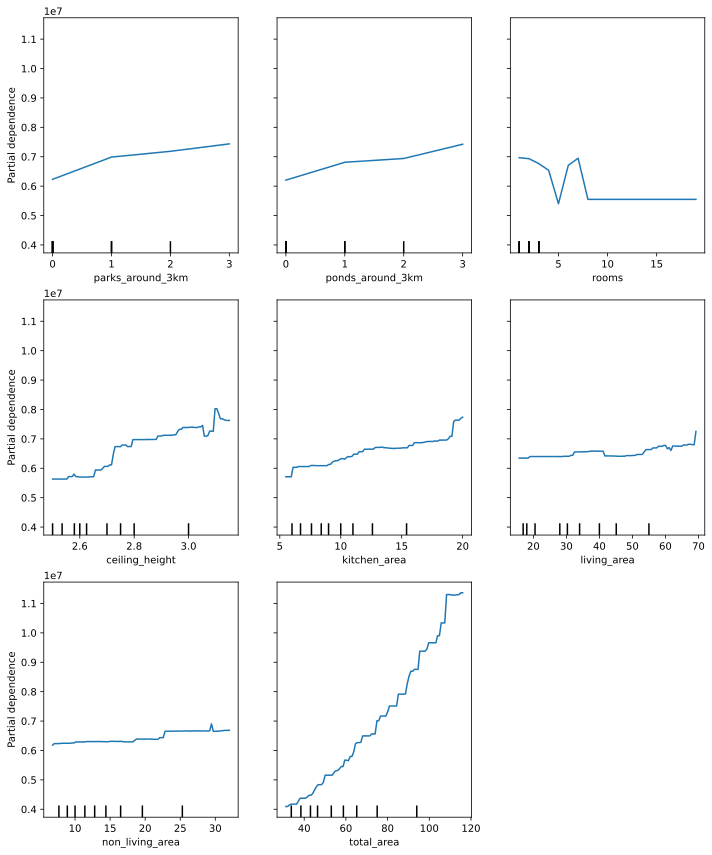

In [121]:
# Предполагаем, что у нас есть DataFrame df с признаками и целевой переменной 'last_price'
features = last_price_features  # пример признаков
X = df[features]
y = df['last_price']

# Создаем и обучаем модель
model = LGBMRegressor(verbosity=-1)
model.fit(X, y)

# Создаем график частичной зависимости
fig, ax = plt.subplots(figsize=(10, 12))
PartialDependenceDisplay.from_estimator(model, X, features, ax=ax)
plt.tight_layout()
plt.show()

#### Анализ графиков частичной зависимости (PDP) для различных факторов, влияющих на стоимость недвижимости:

1. Влияние местоположения и окружения:
   - Близость к паркам и водоемам (в радиусе 3 км) показывает положительную нелинейную зависимость с ценой. Эффект более выражен на начальных этапах и постепенно замедляется.

2. Характеристики помещения:
   - Высота потолков оказывает значительное влияние, с заметным скачком около 2.7 м и дальнейшим ростом.
   - Площадь кухни демонстрирует постепенный рост влияния, усиливающийся при больших значениях.
   - Общая жилая площадь показывает слабый, но стабильный положительный эффект.
   - Зависимость от количества комнат неоднозначна, с нестандартной формой графика, требующей дополнительного анализа.

3. Площадь помещений:
   - Общая площадь имеет сильную положительную зависимость, почти линейную, с более выраженным ростом после 60-70 м².
   - Нежилая площадь оказывает слабое положительное влияние на цену.

Общие выводы:
- Большинство зависимостей нелинейны, что указывает на сложность ценообразования на рынке недвижимости.
- Наиболее значимые факторы: близость к паркам и водоемам, высота потолков, площадь кухни и общая площадь.
- Наблюдаются определенные пороговые значения и "популярные" размеры квартир, отражающиеся в скачках на графиках.
- Общая площадь оказывает гораздо большее влияние на цену, чем нежилая площадь.



#### <a id='m2_price'></a> Стоимость квадратного метра недвижимости

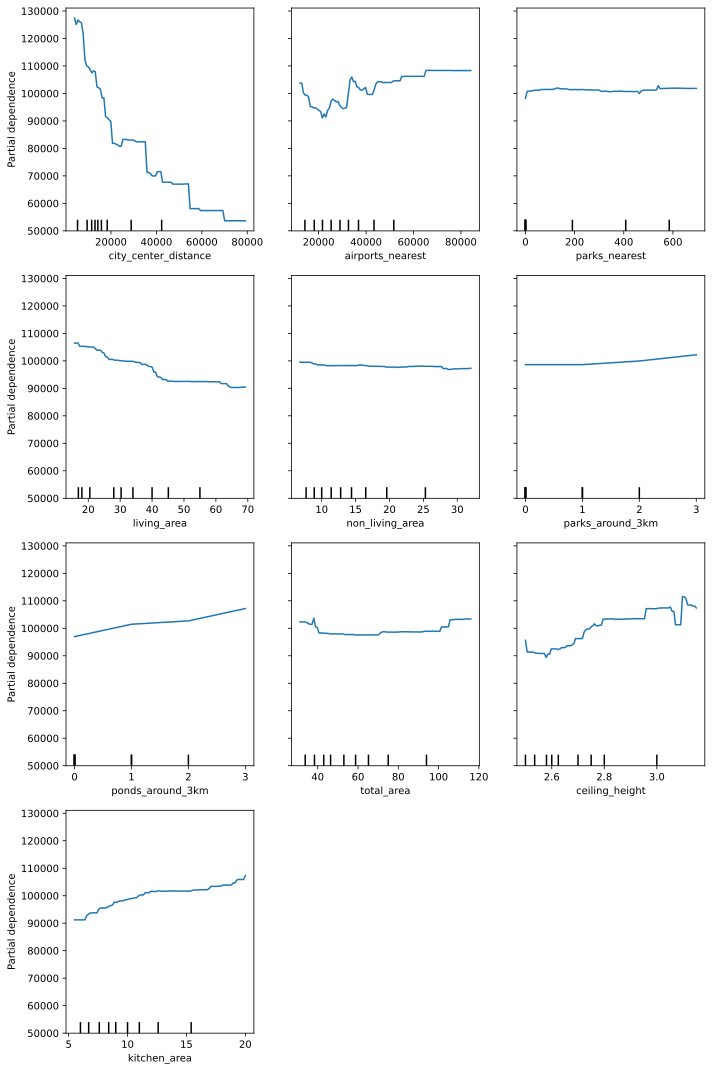

In [122]:

# Предполагаем, что у нас есть DataFrame df с признаками и целевой переменной 'last_price'
features = price_per_m2_corr_features  # пример признаков
X = df[features]
y = df['price_per_m2']

# Создаем и обучаем модель
model = LGBMRegressor(verbosity=-1)
model.fit(X, y)

# Создаем график частичной зависимости
fig, ax = plt.subplots(figsize=(10, 15))
PartialDependenceDisplay.from_estimator(model, X, features, ax=ax)
plt.tight_layout()
plt.show()

#### Анализ влияния различных факторов на стоимость квадратного метра недвижимости:

1. Расположение и окружающая среда:
   - Расстояние до центра города: сильная отрицательная зависимость, резкое падение цены в первые 20-30 км.
   - Близость к аэропортам: неоднозначное влияние, минимум стоимости на расстоянии 20-30 км.
   - Парки и пруды в радиусе 3 км: положительная зависимость, постепенный рост цены.
   - Расстояние до ближайшего парка: слабое положительное влияние.

2. Характеристики жилья:
   - Жилая площадь: отрицательная зависимость, более крупные квартиры дешевле за м².
   - Общая площадь: слабое влияние, небольшое снижение с последующим ростом.
   - Высота потолков: значительная положительная зависимость, особенно после 2.8 м.
   - Площадь кухни: положительная зависимость, более резкий рост после 15 м².
   - Нежилая площадь: очень слабое отрицательное влияние.

Ключевые выводы:
1. Расположение относительно центра города - наиболее значимый фактор стоимости.
2. Экологические факторы (близость к паркам и прудам) повышают цену жилья.
3. Высота потолков и площадь кухни существенно влияют на стоимость.
4. Большая жилая площадь снижает стоимость за квадратный метр.
5. Общая площадь и нежилая площадь оказывают минимальное влияние на цену.
